# Build &amp; Tune Your Own Sequence Aligner

**CMU Pre-College Program in Computational Biology — Module 2 Project**
**Author:** *(your name here)*

> *Change the scoring, and you change the alignment. Which one is right, and how would you know?*

This notebook takes the global (Needleman–Wunsch) and local (Smith–Waterman) alignment code I wrote
in Module 2 and turns it into a small, tunable **sequence-alignment app**. You can change the match
reward, the mismatch penalty and the gap penalty; switch between **global** and **local**; and align
either **DNA** or **protein** (with a choice of BLOSUM / PAM scoring matrices). It reports the alignment,
its score, and readouts like percent identity and gap statistics.

I then use the app to make an argument about **what separates a good alignment from a bad one**.

### What's inside
1. **The algorithms I wrote** — my global and local aligners, verbatim, plus a quick self-test.
2. **Generalizing to substitution matrices** — the same recurrence, extended so it can score proteins.
3. **Readouts** — percent identity, gaps, and friends.
4. **Visualization** — colored alignments and a scoring-matrix heatmap.
5. **The interactive app** — sliders + dropdowns, live.
6. **Good vs bad parameters** — a toy example, a real gene (HBB DNA), and a protein example.
7. **DNA vs protein** — SARS-CoV vs SARS-CoV-2 spike, and the synonymous-mutation story.
8. **The central question** — how to quantify alignment quality when the score itself moves with the parameters.
9. **Stretch** — the gap problem (affine gaps), and a sanity check against Biopython.

Everything runs top-to-bottom with **Runtime → Run all**. All sequences are embedded, so nothing needs
to be uploaded and there is no dependence on NCBI being reachable during a demo. (Accession numbers are
noted where relevant so the data is still reproducible.)


## 0. Setup

Only the standard scientific stack is needed: `matplotlib` for figures and `ipywidgets` for the interactive
app (both are pre-installed in Colab). The alignment engine itself is plain Python — it *is* my code, so
there is nothing to `pip install` to run the core of the project. (The optional Biopython sanity check at
the very end installs one extra package.)


In [1]:
import math, random
import matplotlib.pyplot as plt
from IPython.display import HTML, display

try:
    import ipywidgets as widgets
    HAVE_WIDGETS = True
except Exception:
    HAVE_WIDGETS = False

%matplotlib inline
print("Setup complete. Interactive widgets available:", HAVE_WIDGETS)

Setup complete. Interactive widgets available: True


## 1. The algorithms I wrote

Both aligners are filled-in dynamic-programming tables. For sequences $s_1$ (length $n$) and $s_2$
(length $m$), the cell $T[i][j]$ holds the best score for aligning the first $i$ letters of $s_1$ with
the first $j$ letters of $s_2$. Each cell is the best of three moves:

$$T[i][j] = \max \begin{cases} T[i-1][j-1] + \text{(match reward or }-\text{mismatch penalty)} & \text{diagonal} \\ T[i-1][j] - \text{gap} & \text{up (gap in }s_2) \\ T[i][j-1] - \text{gap} & \text{left (gap in }s_1) \end{cases}$$

**My scoring convention** (used throughout): `match` is a *reward* that is **added**; `mismatch` and
`gap` are *penalty magnitudes* (positive numbers) that are **subtracted**. So `mismatch=1` means a
mismatch costs $-1$, and `gap=2` means each gap column costs $-2$.

- **Global (Needleman–Wunsch)** initializes the first row/column with growing gap penalties, so the whole
  of both sequences must be aligned end to end.
- **Local (Smith–Waterman)** is the same recurrence with one extra rule — every cell is **floored at 0** —
  so the alignment is free to start and stop anywhere, finding the single best-matching sub-region.

The four functions below are exactly the module code (`globalAlignmentScore.py`, `globalAlignment.py`,
`localAlignmentScore.py`, `localAlignment.py`).

In [2]:
# ---- globalAlignmentScore.py ----
def global_score_table(str1, str2, match, mismatch, gap):
    """Returns a 2-D array holding dynamic programming scores for global alignment."""
    if len(str1) == 0 or len(str2) == 0:
        raise ValueError("Error: empty string given to global_score_table.")
    num_rows = len(str1) + 1
    num_cols = len(str2) + 1
    score_table = [[0.0] * num_cols for _ in range(num_rows)]
    for j in range(1, num_cols):
        score_table[0][j] = float(j) * (-gap)
    for i in range(1, num_rows):
        score_table[i][0] = float(i) * (-gap)
    for i in range(1, num_rows):
        for j in range(1, num_cols):
            up_value = score_table[i-1][j] - gap
            left_value = score_table[i][j-1] - gap
            diagonal_weight = match if str1[i-1] == str2[j-1] else -mismatch
            diag_value = score_table[i-1][j-1] + diagonal_weight
            score_table[i][j] = max(up_value, left_value, diag_value)
    return score_table


# ---- globalAlignment.py ----
def global_alignment(str1, str2, match, mismatch, gap):
    """Returns a maximum score global alignment of two strings using the given penalties."""
    alignment = ["", ""]
    scoring_matrix = global_score_table(str1, str2, match, mismatch, gap)
    r = len(str1)
    c = len(str2)
    while r > 0 and c > 0:
        if scoring_matrix[r][c] == scoring_matrix[r-1][c] - gap:
            alignment[0] = str1[r-1] + alignment[0]; alignment[1] = "-" + alignment[1]; r -= 1
        elif scoring_matrix[r][c] == scoring_matrix[r][c-1] - gap:
            alignment[0] = "-" + alignment[0]; alignment[1] = str2[c-1] + alignment[1]; c -= 1
        elif str1[r-1] != str2[c-1] and scoring_matrix[r][c] == scoring_matrix[r-1][c-1] - mismatch:
            alignment[0] = str1[r-1] + alignment[0]; alignment[1] = str2[c-1] + alignment[1]; r -= 1; c -= 1
        elif str1[r-1] == str2[c-1] and scoring_matrix[r][c] == scoring_matrix[r-1][c-1] + match:
            alignment[0] = str1[r-1] + alignment[0]; alignment[1] = str2[c-1] + alignment[1]; r -= 1; c -= 1
        else:
            raise ValueError("Error: unexpected state in global alignment backtracking.")
    while r > 0:
        alignment[0] = str1[r-1] + alignment[0]; alignment[1] = "-" + alignment[1]; r -= 1
    while c > 0:
        alignment[0] = "-" + alignment[0]; alignment[1] = str2[c-1] + alignment[1]; c -= 1
    return alignment

In [3]:
# ---- localAlignmentScore.py ----
def local_score_table(str1, str2, match, mismatch, gap):
    """Local (Smith-Waterman) score table: identical to the global recurrence but every cell is floored at 0."""
    if len(str1) == 0 or len(str2) == 0:
        raise ValueError("Error: empty string given to local_score_table.")
    num_rows = len(str1) + 1
    num_cols = len(str2) + 1
    score_table = [[0.0] * num_cols for _ in range(num_rows)]
    # First row/column stay 0: a local alignment may start anywhere for free.
    for i in range(1, num_rows):
        for j in range(1, num_cols):
            up_value = score_table[i-1][j] - gap
            left_value = score_table[i][j-1] - gap
            diagonal_weight = match if str1[i-1] == str2[j-1] else -mismatch
            diag_value = score_table[i-1][j-1] + diagonal_weight
            # The floor at 0 is the one line that turns Needleman-Wunsch into Smith-Waterman.
            score_table[i][j] = max(0.0, up_value, left_value, diag_value)
    return score_table


# ---- localAlignment.py ----
def local_alignment(str1, str2, match, mismatch, gap):
    """Highest-scoring local alignment, with the start/end indices of the aligned substring in each string."""
    alignment = ["", ""]
    scoring_matrix = local_score_table(str1, str2, match, mismatch, gap)
    # The best local alignment ends at the highest-scoring cell anywhere in the table.
    best_score = 0.0; r = 0; c = 0
    for i in range(len(scoring_matrix)):
        for j in range(len(scoring_matrix[i])):
            if scoring_matrix[i][j] > best_score:
                best_score = scoring_matrix[i][j]; r = i; c = j
    end1 = r; end2 = c
    # Backtrack until we reach a 0, which marks the start of the local alignment.
    while r > 0 and c > 0 and scoring_matrix[r][c] > 0:
        if scoring_matrix[r][c] == scoring_matrix[r-1][c] - gap:
            alignment[0] = str1[r-1] + alignment[0]; alignment[1] = "-" + alignment[1]; r -= 1
        elif scoring_matrix[r][c] == scoring_matrix[r][c-1] - gap:
            alignment[0] = "-" + alignment[0]; alignment[1] = str2[c-1] + alignment[1]; c -= 1
        elif str1[r-1] != str2[c-1] and scoring_matrix[r][c] == scoring_matrix[r-1][c-1] - mismatch:
            alignment[0] = str1[r-1] + alignment[0]; alignment[1] = str2[c-1] + alignment[1]; r -= 1; c -= 1
        elif str1[r-1] == str2[c-1] and scoring_matrix[r][c] == scoring_matrix[r-1][c-1] + match:
            alignment[0] = str1[r-1] + alignment[0]; alignment[1] = str2[c-1] + alignment[1]; r -= 1; c -= 1
        else:
            raise ValueError("Error: unexpected state in local alignment backtracking.")
    start1 = r; start2 = c
    return alignment, start1, end1, start2, end2

**Quick self-test.** A global alignment of two tiny strings, and the classic Smith–Waterman textbook
example (`GGTTGACTA` vs `TGTTACGG` with match `+3`, mismatch `-3`, gap `-2`), whose optimal local score is
**13** with alignment `GTTGAC / GTT-AC`. If these pass, the algorithms are behaving.

In [4]:
# Global on a tiny pair
g = global_alignment("GATTACA", "GCATGCG", match=1, mismatch=1, gap=2)
print("GLOBAL")
print(" ", g[0])
print(" ", g[1])

# Local on the textbook example
aln, s1, e1, s2, e2 = local_alignment("GGTTGACTA", "TGTTACGG", match=3, mismatch=3, gap=2)
print("\nLOCAL (Smith-Waterman textbook example)")
print(" ", aln[0])
print(" ", aln[1])
best = max(max(row) for row in local_score_table("GGTTGACTA", "TGTTACGG", 3, 3, 2))
print("  best local score:", best, "(expected 13)")
assert best == 13.0, "Smith-Waterman self-test failed!"
print("  self-test passed.")

GLOBAL
  GATTACA
  GCATGCG

LOCAL (Smith-Waterman textbook example)
  GTTGAC
  GTT-AC
  best local score: 13.0 (expected 13)
  self-test passed.


## 2. Generalizing to substitution matrices (so it can score proteins too)

Flat match/mismatch is fine for DNA, where the four bases are interchangeable and every mismatch is "just
wrong." Proteins are different: swapping leucine for isoleucine (both greasy, similar size) barely dents a
protein, while swapping tryptophan for proline can wreck it. A single `mismatch` number can't express that.
Biologists encode it in a **substitution matrix** (BLOSUM, PAM) — a 20×20 table giving a score to *every*
amino-acid pair, derived from how often those swaps actually survive in real evolution.

So I generalize the exact same recurrence: instead of `match / -mismatch` on the diagonal, look the pair up
in a matrix `sub[a][b]`. Flat DNA scoring becomes the special case `sub[a][b] = match if a==b else -mismatch`.
The `align()` function below is that one general engine; it does global and local, DNA and protein.

*(One small implementation note: for readability my traceback prefers the diagonal move on ties, whereas the
module code above prefers gaps. Both are optimal — they can only differ on tied paths — so the **score** is
identical, which is exactly what the assertion below checks.)*

In [5]:
def align(seq1, seq2, sub, gap, mode="global", name1="seq1", name2="seq2"):
    """
    General pairwise aligner: the same DP recurrence as my module code, but the
    diagonal score comes from a substitution matrix `sub` (a dict-of-dicts), so it
    handles both DNA (flat) and protein (BLOSUM/PAM). `gap` is a positive penalty
    magnitude. mode = 'global' (Needleman-Wunsch) or 'local' (Smith-Waterman).
    Returns a dict with the two aligned rows, the score, and (for local) coordinates.
    """
    local = (mode == "local")
    n, m = len(seq1), len(seq2)

    # ---- fill the score table ----
    T = [[0.0] * (m + 1) for _ in range(n + 1)]
    if not local:
        for j in range(1, m + 1):
            T[0][j] = -gap * j
        for i in range(1, n + 1):
            T[i][0] = -gap * i
    for i in range(1, n + 1):
        row = T[i]; prev = T[i - 1]; subrow = sub[seq1[i - 1]]
        for j in range(1, m + 1):
            diag = prev[j - 1] + subrow[seq2[j - 1]]
            up = prev[j] - gap
            left = row[j - 1] - gap
            best = diag if diag >= up else up
            if left > best:
                best = left
            if local and best < 0.0:
                best = 0.0
            row[j] = best

    # ---- find where the traceback starts ----
    if local:
        best = 0.0; i = j = 0
        for r in range(n + 1):
            Tr = T[r]
            for c in range(m + 1):
                if Tr[c] > best:
                    best = Tr[c]; i, j = r, c
        score = best
    else:
        i, j = n, m
        score = T[n][m]
    end1, end2 = i, j

    # ---- traceback ----
    top = []; bot = []
    while (i > 0 and j > 0) and (not local or T[i][j] > 0):
        if T[i][j] == T[i - 1][j - 1] + sub[seq1[i - 1]][seq2[j - 1]]:
            top.append(seq1[i - 1]); bot.append(seq2[j - 1]); i -= 1; j -= 1
        elif T[i][j] == T[i - 1][j] - gap:
            top.append(seq1[i - 1]); bot.append("-"); i -= 1
        elif T[i][j] == T[i][j - 1] - gap:
            top.append("-"); bot.append(seq2[j - 1]); j -= 1
        else:
            break
    if not local:
        while i > 0:
            top.append(seq1[i - 1]); bot.append("-"); i -= 1
        while j > 0:
            top.append("-"); bot.append(seq2[j - 1]); j -= 1
    start1, start2 = i, j
    top.reverse(); bot.reverse()

    return {"name1": name1, "name2": name2, "top": "".join(top), "bottom": "".join(bot),
            "score": score, "mode": mode, "gap": gap,
            "start1": start1, "end1": end1, "start2": start2, "end2": end2}


def dna_matrix(match=1.0, mismatch=1.0, alphabet="ACGTN"):
    """Flat DNA scoring expressed as a substitution matrix: +match on the diagonal, -mismatch off it."""
    return {a: {b: (match if a == b else -mismatch) for b in alphabet} for a in alphabet}


# ---- prove the general engine agrees with my original module code on DNA ----
_a, _b = "ACGTGTCATGCATTAGCATG", "ACGTATCATGCATTTGCATG"
_orig = global_alignment(_a, _b, 1, 1, 2)


def _score_flat(top, bot, match, mismatch, gap):
    s = 0.0
    for x, y in zip(top, bot):
        if x == "-" or y == "-": s -= gap
        elif x == y: s += match
        else: s -= mismatch
    return s


_gen = align(_a, _b, dna_matrix(1, 1), 2, "global")
print("original module score:", _score_flat(_orig[0], _orig[1], 1, 1, 2))
print("general engine score :", _gen["score"])
assert _score_flat(_orig[0], _orig[1], 1, 1, 2) == _gen["score"], "engines disagree!"
print("General engine reproduces my module code on DNA.  OK")

original module score: 16.0
general engine score : 16.0
General engine reproduces my module code on DNA.  OK


### Scoring matrices

The protein matrices below (BLOSUM62, BLOSUM45, BLOSUM80, PAM250, PAM30) are the standard published tables.
Rules of thumb: **BLOSUM62** is the general-purpose default; higher-numbered BLOSUM (80) and *lower*-numbered
PAM (30) are tuned for **closely related** sequences; lower BLOSUM (45) and higher PAM (250) are tuned for
**distant** ones. Choosing the matrix is itself a modeling decision — one we will feel the effect of later.

In [6]:
MATRICES = {"BLOSUM62": {"A": {"A": 4, "R": -1, "N": -2, "D": -2, "C": 0, "Q": -1, "E": -1, "G": 0, "H": -2, "I": -1, "L": -1, "K": -1, "M": -1, "F": -2, "P": -1, "S": 1, "T": 0, "W": -3, "Y": -2, "V": 0, "B": -2, "Z": -1, "X": 0, "*": -4}, "R": {"A": -1, "R": 5, "N": 0, "D": -2, "C": -3, "Q": 1, "E": 0, "G": -2, "H": 0, "I": -3, "L": -2, "K": 2, "M": -1, "F": -3, "P": -2, "S": -1, "T": -1, "W": -3, "Y": -2, "V": -3, "B": -1, "Z": 0, "X": -1, "*": -4}, "N": {"A": -2, "R": 0, "N": 6, "D": 1, "C": -3, "Q": 0, "E": 0, "G": 0, "H": 1, "I": -3, "L": -3, "K": 0, "M": -2, "F": -3, "P": -2, "S": 1, "T": 0, "W": -4, "Y": -2, "V": -3, "B": 3, "Z": 0, "X": -1, "*": -4}, "D": {"A": -2, "R": -2, "N": 1, "D": 6, "C": -3, "Q": 0, "E": 2, "G": -1, "H": -1, "I": -3, "L": -4, "K": -1, "M": -3, "F": -3, "P": -1, "S": 0, "T": -1, "W": -4, "Y": -3, "V": -3, "B": 4, "Z": 1, "X": -1, "*": -4}, "C": {"A": 0, "R": -3, "N": -3, "D": -3, "C": 9, "Q": -3, "E": -4, "G": -3, "H": -3, "I": -1, "L": -1, "K": -3, "M": -1, "F": -2, "P": -3, "S": -1, "T": -1, "W": -2, "Y": -2, "V": -1, "B": -3, "Z": -3, "X": -2, "*": -4}, "Q": {"A": -1, "R": 1, "N": 0, "D": 0, "C": -3, "Q": 5, "E": 2, "G": -2, "H": 0, "I": -3, "L": -2, "K": 1, "M": 0, "F": -3, "P": -1, "S": 0, "T": -1, "W": -2, "Y": -1, "V": -2, "B": 0, "Z": 3, "X": -1, "*": -4}, "E": {"A": -1, "R": 0, "N": 0, "D": 2, "C": -4, "Q": 2, "E": 5, "G": -2, "H": 0, "I": -3, "L": -3, "K": 1, "M": -2, "F": -3, "P": -1, "S": 0, "T": -1, "W": -3, "Y": -2, "V": -2, "B": 1, "Z": 4, "X": -1, "*": -4}, "G": {"A": 0, "R": -2, "N": 0, "D": -1, "C": -3, "Q": -2, "E": -2, "G": 6, "H": -2, "I": -4, "L": -4, "K": -2, "M": -3, "F": -3, "P": -2, "S": 0, "T": -2, "W": -2, "Y": -3, "V": -3, "B": -1, "Z": -2, "X": -1, "*": -4}, "H": {"A": -2, "R": 0, "N": 1, "D": -1, "C": -3, "Q": 0, "E": 0, "G": -2, "H": 8, "I": -3, "L": -3, "K": -1, "M": -2, "F": -1, "P": -2, "S": -1, "T": -2, "W": -2, "Y": 2, "V": -3, "B": 0, "Z": 0, "X": -1, "*": -4}, "I": {"A": -1, "R": -3, "N": -3, "D": -3, "C": -1, "Q": -3, "E": -3, "G": -4, "H": -3, "I": 4, "L": 2, "K": -3, "M": 1, "F": 0, "P": -3, "S": -2, "T": -1, "W": -3, "Y": -1, "V": 3, "B": -3, "Z": -3, "X": -1, "*": -4}, "L": {"A": -1, "R": -2, "N": -3, "D": -4, "C": -1, "Q": -2, "E": -3, "G": -4, "H": -3, "I": 2, "L": 4, "K": -2, "M": 2, "F": 0, "P": -3, "S": -2, "T": -1, "W": -2, "Y": -1, "V": 1, "B": -4, "Z": -3, "X": -1, "*": -4}, "K": {"A": -1, "R": 2, "N": 0, "D": -1, "C": -3, "Q": 1, "E": 1, "G": -2, "H": -1, "I": -3, "L": -2, "K": 5, "M": -1, "F": -3, "P": -1, "S": 0, "T": -1, "W": -3, "Y": -2, "V": -2, "B": 0, "Z": 1, "X": -1, "*": -4}, "M": {"A": -1, "R": -1, "N": -2, "D": -3, "C": -1, "Q": 0, "E": -2, "G": -3, "H": -2, "I": 1, "L": 2, "K": -1, "M": 5, "F": 0, "P": -2, "S": -1, "T": -1, "W": -1, "Y": -1, "V": 1, "B": -3, "Z": -1, "X": -1, "*": -4}, "F": {"A": -2, "R": -3, "N": -3, "D": -3, "C": -2, "Q": -3, "E": -3, "G": -3, "H": -1, "I": 0, "L": 0, "K": -3, "M": 0, "F": 6, "P": -4, "S": -2, "T": -2, "W": 1, "Y": 3, "V": -1, "B": -3, "Z": -3, "X": -1, "*": -4}, "P": {"A": -1, "R": -2, "N": -2, "D": -1, "C": -3, "Q": -1, "E": -1, "G": -2, "H": -2, "I": -3, "L": -3, "K": -1, "M": -2, "F": -4, "P": 7, "S": -1, "T": -1, "W": -4, "Y": -3, "V": -2, "B": -2, "Z": -1, "X": -2, "*": -4}, "S": {"A": 1, "R": -1, "N": 1, "D": 0, "C": -1, "Q": 0, "E": 0, "G": 0, "H": -1, "I": -2, "L": -2, "K": 0, "M": -1, "F": -2, "P": -1, "S": 4, "T": 1, "W": -3, "Y": -2, "V": -2, "B": 0, "Z": 0, "X": 0, "*": -4}, "T": {"A": 0, "R": -1, "N": 0, "D": -1, "C": -1, "Q": -1, "E": -1, "G": -2, "H": -2, "I": -1, "L": -1, "K": -1, "M": -1, "F": -2, "P": -1, "S": 1, "T": 5, "W": -2, "Y": -2, "V": 0, "B": -1, "Z": -1, "X": 0, "*": -4}, "W": {"A": -3, "R": -3, "N": -4, "D": -4, "C": -2, "Q": -2, "E": -3, "G": -2, "H": -2, "I": -3, "L": -2, "K": -3, "M": -1, "F": 1, "P": -4, "S": -3, "T": -2, "W": 11, "Y": 2, "V": -3, "B": -4, "Z": -3, "X": -2, "*": -4}, "Y": {"A": -2, "R": -2, "N": -2, "D": -3, "C": -2, "Q": -1, "E": -2, "G": -3, "H": 2, "I": -1, "L": -1, "K": -2, "M": -1, "F": 3, "P": -3, "S": -2, "T": -2, "W": 2, "Y": 7, "V": -1, "B": -3, "Z": -2, "X": -1, "*": -4}, "V": {"A": 0, "R": -3, "N": -3, "D": -3, "C": -1, "Q": -2, "E": -2, "G": -3, "H": -3, "I": 3, "L": 1, "K": -2, "M": 1, "F": -1, "P": -2, "S": -2, "T": 0, "W": -3, "Y": -1, "V": 4, "B": -3, "Z": -2, "X": -1, "*": -4}, "B": {"A": -2, "R": -1, "N": 3, "D": 4, "C": -3, "Q": 0, "E": 1, "G": -1, "H": 0, "I": -3, "L": -4, "K": 0, "M": -3, "F": -3, "P": -2, "S": 0, "T": -1, "W": -4, "Y": -3, "V": -3, "B": 4, "Z": 1, "X": -1, "*": -4}, "Z": {"A": -1, "R": 0, "N": 0, "D": 1, "C": -3, "Q": 3, "E": 4, "G": -2, "H": 0, "I": -3, "L": -3, "K": 1, "M": -1, "F": -3, "P": -1, "S": 0, "T": -1, "W": -3, "Y": -2, "V": -2, "B": 1, "Z": 4, "X": -1, "*": -4}, "X": {"A": 0, "R": -1, "N": -1, "D": -1, "C": -2, "Q": -1, "E": -1, "G": -1, "H": -1, "I": -1, "L": -1, "K": -1, "M": -1, "F": -1, "P": -2, "S": 0, "T": 0, "W": -2, "Y": -1, "V": -1, "B": -1, "Z": -1, "X": -1, "*": -4}, "*": {"A": -4, "R": -4, "N": -4, "D": -4, "C": -4, "Q": -4, "E": -4, "G": -4, "H": -4, "I": -4, "L": -4, "K": -4, "M": -4, "F": -4, "P": -4, "S": -4, "T": -4, "W": -4, "Y": -4, "V": -4, "B": -4, "Z": -4, "X": -4, "*": 1}}, "BLOSUM45": {"A": {"A": 5, "R": -2, "N": -1, "D": -2, "C": -1, "Q": -1, "E": -1, "G": 0, "H": -2, "I": -1, "L": -1, "K": -1, "M": -1, "F": -2, "P": -1, "S": 1, "T": 0, "W": -2, "Y": -2, "V": 0, "B": -1, "Z": -1, "X": 0, "*": -5}, "R": {"A": -2, "R": 7, "N": 0, "D": -1, "C": -3, "Q": 1, "E": 0, "G": -2, "H": 0, "I": -3, "L": -2, "K": 3, "M": -1, "F": -2, "P": -2, "S": -1, "T": -1, "W": -2, "Y": -1, "V": -2, "B": -1, "Z": 0, "X": -1, "*": -5}, "N": {"A": -1, "R": 0, "N": 6, "D": 2, "C": -2, "Q": 0, "E": 0, "G": 0, "H": 1, "I": -2, "L": -3, "K": 0, "M": -2, "F": -2, "P": -2, "S": 1, "T": 0, "W": -4, "Y": -2, "V": -3, "B": 4, "Z": 0, "X": -1, "*": -5}, "D": {"A": -2, "R": -1, "N": 2, "D": 7, "C": -3, "Q": 0, "E": 2, "G": -1, "H": 0, "I": -4, "L": -3, "K": 0, "M": -3, "F": -4, "P": -1, "S": 0, "T": -1, "W": -4, "Y": -2, "V": -3, "B": 5, "Z": 1, "X": -1, "*": -5}, "C": {"A": -1, "R": -3, "N": -2, "D": -3, "C": 12, "Q": -3, "E": -3, "G": -3, "H": -3, "I": -3, "L": -2, "K": -3, "M": -2, "F": -2, "P": -4, "S": -1, "T": -1, "W": -5, "Y": -3, "V": -1, "B": -2, "Z": -3, "X": -2, "*": -5}, "Q": {"A": -1, "R": 1, "N": 0, "D": 0, "C": -3, "Q": 6, "E": 2, "G": -2, "H": 1, "I": -2, "L": -2, "K": 1, "M": 0, "F": -4, "P": -1, "S": 0, "T": -1, "W": -2, "Y": -1, "V": -3, "B": 0, "Z": 4, "X": -1, "*": -5}, "E": {"A": -1, "R": 0, "N": 0, "D": 2, "C": -3, "Q": 2, "E": 6, "G": -2, "H": 0, "I": -3, "L": -2, "K": 1, "M": -2, "F": -3, "P": 0, "S": 0, "T": -1, "W": -3, "Y": -2, "V": -3, "B": 1, "Z": 4, "X": -1, "*": -5}, "G": {"A": 0, "R": -2, "N": 0, "D": -1, "C": -3, "Q": -2, "E": -2, "G": 7, "H": -2, "I": -4, "L": -3, "K": -2, "M": -2, "F": -3, "P": -2, "S": 0, "T": -2, "W": -2, "Y": -3, "V": -3, "B": -1, "Z": -2, "X": -1, "*": -5}, "H": {"A": -2, "R": 0, "N": 1, "D": 0, "C": -3, "Q": 1, "E": 0, "G": -2, "H": 10, "I": -3, "L": -2, "K": -1, "M": 0, "F": -2, "P": -2, "S": -1, "T": -2, "W": -3, "Y": 2, "V": -3, "B": 0, "Z": 0, "X": -1, "*": -5}, "I": {"A": -1, "R": -3, "N": -2, "D": -4, "C": -3, "Q": -2, "E": -3, "G": -4, "H": -3, "I": 5, "L": 2, "K": -3, "M": 2, "F": 0, "P": -2, "S": -2, "T": -1, "W": -2, "Y": 0, "V": 3, "B": -3, "Z": -3, "X": -1, "*": -5}, "L": {"A": -1, "R": -2, "N": -3, "D": -3, "C": -2, "Q": -2, "E": -2, "G": -3, "H": -2, "I": 2, "L": 5, "K": -3, "M": 2, "F": 1, "P": -3, "S": -3, "T": -1, "W": -2, "Y": 0, "V": 1, "B": -3, "Z": -2, "X": -1, "*": -5}, "K": {"A": -1, "R": 3, "N": 0, "D": 0, "C": -3, "Q": 1, "E": 1, "G": -2, "H": -1, "I": -3, "L": -3, "K": 5, "M": -1, "F": -3, "P": -1, "S": -1, "T": -1, "W": -2, "Y": -1, "V": -2, "B": 0, "Z": 1, "X": -1, "*": -5}, "M": {"A": -1, "R": -1, "N": -2, "D": -3, "C": -2, "Q": 0, "E": -2, "G": -2, "H": 0, "I": 2, "L": 2, "K": -1, "M": 6, "F": 0, "P": -2, "S": -2, "T": -1, "W": -2, "Y": 0, "V": 1, "B": -2, "Z": -1, "X": -1, "*": -5}, "F": {"A": -2, "R": -2, "N": -2, "D": -4, "C": -2, "Q": -4, "E": -3, "G": -3, "H": -2, "I": 0, "L": 1, "K": -3, "M": 0, "F": 8, "P": -3, "S": -2, "T": -1, "W": 1, "Y": 3, "V": 0, "B": -3, "Z": -3, "X": -1, "*": -5}, "P": {"A": -1, "R": -2, "N": -2, "D": -1, "C": -4, "Q": -1, "E": 0, "G": -2, "H": -2, "I": -2, "L": -3, "K": -1, "M": -2, "F": -3, "P": 9, "S": -1, "T": -1, "W": -3, "Y": -3, "V": -3, "B": -2, "Z": -1, "X": -1, "*": -5}, "S": {"A": 1, "R": -1, "N": 1, "D": 0, "C": -1, "Q": 0, "E": 0, "G": 0, "H": -1, "I": -2, "L": -3, "K": -1, "M": -2, "F": -2, "P": -1, "S": 4, "T": 2, "W": -4, "Y": -2, "V": -1, "B": 0, "Z": 0, "X": 0, "*": -5}, "T": {"A": 0, "R": -1, "N": 0, "D": -1, "C": -1, "Q": -1, "E": -1, "G": -2, "H": -2, "I": -1, "L": -1, "K": -1, "M": -1, "F": -1, "P": -1, "S": 2, "T": 5, "W": -3, "Y": -1, "V": 0, "B": 0, "Z": -1, "X": 0, "*": -5}, "W": {"A": -2, "R": -2, "N": -4, "D": -4, "C": -5, "Q": -2, "E": -3, "G": -2, "H": -3, "I": -2, "L": -2, "K": -2, "M": -2, "F": 1, "P": -3, "S": -4, "T": -3, "W": 15, "Y": 3, "V": -3, "B": -4, "Z": -2, "X": -2, "*": -5}, "Y": {"A": -2, "R": -1, "N": -2, "D": -2, "C": -3, "Q": -1, "E": -2, "G": -3, "H": 2, "I": 0, "L": 0, "K": -1, "M": 0, "F": 3, "P": -3, "S": -2, "T": -1, "W": 3, "Y": 8, "V": -1, "B": -2, "Z": -2, "X": -1, "*": -5}, "V": {"A": 0, "R": -2, "N": -3, "D": -3, "C": -1, "Q": -3, "E": -3, "G": -3, "H": -3, "I": 3, "L": 1, "K": -2, "M": 1, "F": 0, "P": -3, "S": -1, "T": 0, "W": -3, "Y": -1, "V": 5, "B": -3, "Z": -3, "X": -1, "*": -5}, "B": {"A": -1, "R": -1, "N": 4, "D": 5, "C": -2, "Q": 0, "E": 1, "G": -1, "H": 0, "I": -3, "L": -3, "K": 0, "M": -2, "F": -3, "P": -2, "S": 0, "T": 0, "W": -4, "Y": -2, "V": -3, "B": 4, "Z": 2, "X": -1, "*": -5}, "Z": {"A": -1, "R": 0, "N": 0, "D": 1, "C": -3, "Q": 4, "E": 4, "G": -2, "H": 0, "I": -3, "L": -2, "K": 1, "M": -1, "F": -3, "P": -1, "S": 0, "T": -1, "W": -2, "Y": -2, "V": -3, "B": 2, "Z": 4, "X": -1, "*": -5}, "X": {"A": 0, "R": -1, "N": -1, "D": -1, "C": -2, "Q": -1, "E": -1, "G": -1, "H": -1, "I": -1, "L": -1, "K": -1, "M": -1, "F": -1, "P": -1, "S": 0, "T": 0, "W": -2, "Y": -1, "V": -1, "B": -1, "Z": -1, "X": -1, "*": -5}, "*": {"A": -5, "R": -5, "N": -5, "D": -5, "C": -5, "Q": -5, "E": -5, "G": -5, "H": -5, "I": -5, "L": -5, "K": -5, "M": -5, "F": -5, "P": -5, "S": -5, "T": -5, "W": -5, "Y": -5, "V": -5, "B": -5, "Z": -5, "X": -5, "*": 1}}, "BLOSUM80": {"A": {"A": 7, "R": -3, "N": -3, "D": -3, "C": -1, "Q": -2, "E": -2, "G": 0, "H": -3, "I": -3, "L": -3, "K": -1, "M": -2, "F": -4, "P": -1, "S": 2, "T": 0, "W": -5, "Y": -4, "V": -1, "B": -3, "Z": -2, "X": -1, "*": -8}, "R": {"A": -3, "R": 9, "N": -1, "D": -3, "C": -6, "Q": 1, "E": -1, "G": -4, "H": 0, "I": -5, "L": -4, "K": 3, "M": -3, "F": -5, "P": -3, "S": -2, "T": -2, "W": -5, "Y": -4, "V": -4, "B": -2, "Z": 0, "X": -2, "*": -8}, "N": {"A": -3, "R": -1, "N": 9, "D": 2, "C": -5, "Q": 0, "E": -1, "G": -1, "H": 1, "I": -6, "L": -6, "K": 0, "M": -4, "F": -6, "P": -4, "S": 1, "T": 0, "W": -7, "Y": -4, "V": -5, "B": 5, "Z": -1, "X": -2, "*": -8}, "D": {"A": -3, "R": -3, "N": 2, "D": 10, "C": -7, "Q": -1, "E": 2, "G": -3, "H": -2, "I": -7, "L": -7, "K": -2, "M": -6, "F": -6, "P": -3, "S": -1, "T": -2, "W": -8, "Y": -6, "V": -6, "B": 6, "Z": 1, "X": -3, "*": -8}, "C": {"A": -1, "R": -6, "N": -5, "D": -7, "C": 13, "Q": -5, "E": -7, "G": -6, "H": -7, "I": -2, "L": -3, "K": -6, "M": -3, "F": -4, "P": -6, "S": -2, "T": -2, "W": -5, "Y": -5, "V": -2, "B": -6, "Z": -7, "X": -4, "*": -8}, "Q": {"A": -2, "R": 1, "N": 0, "D": -1, "C": -5, "Q": 9, "E": 3, "G": -4, "H": 1, "I": -5, "L": -4, "K": 2, "M": -1, "F": -5, "P": -3, "S": -1, "T": -1, "W": -4, "Y": -3, "V": -4, "B": -1, "Z": 5, "X": -2, "*": -8}, "E": {"A": -2, "R": -1, "N": -1, "D": 2, "C": -7, "Q": 3, "E": 8, "G": -4, "H": 0, "I": -6, "L": -6, "K": 1, "M": -4, "F": -6, "P": -2, "S": -1, "T": -2, "W": -6, "Y": -5, "V": -4, "B": 1, "Z": 6, "X": -2, "*": -8}, "G": {"A": 0, "R": -4, "N": -1, "D": -3, "C": -6, "Q": -4, "E": -4, "G": 9, "H": -4, "I": -7, "L": -7, "K": -3, "M": -5, "F": -6, "P": -5, "S": -1, "T": -3, "W": -6, "Y": -6, "V": -6, "B": -2, "Z": -4, "X": -3, "*": -8}, "H": {"A": -3, "R": 0, "N": 1, "D": -2, "C": -7, "Q": 1, "E": 0, "G": -4, "H": 12, "I": -6, "L": -5, "K": -1, "M": -4, "F": -2, "P": -4, "S": -2, "T": -3, "W": -4, "Y": 3, "V": -5, "B": -1, "Z": 0, "X": -2, "*": -8}, "I": {"A": -3, "R": -5, "N": -6, "D": -7, "C": -2, "Q": -5, "E": -6, "G": -7, "H": -6, "I": 7, "L": 2, "K": -5, "M": 2, "F": -1, "P": -5, "S": -4, "T": -2, "W": -5, "Y": -3, "V": 4, "B": -6, "Z": -6, "X": -2, "*": -8}, "L": {"A": -3, "R": -4, "N": -6, "D": -7, "C": -3, "Q": -4, "E": -6, "G": -7, "H": -5, "I": 2, "L": 6, "K": -4, "M": 3, "F": 0, "P": -5, "S": -4, "T": -3, "W": -4, "Y": -2, "V": 1, "B": -7, "Z": -5, "X": -2, "*": -8}, "K": {"A": -1, "R": 3, "N": 0, "D": -2, "C": -6, "Q": 2, "E": 1, "G": -3, "H": -1, "I": -5, "L": -4, "K": 8, "M": -3, "F": -5, "P": -2, "S": -1, "T": -1, "W": -6, "Y": -4, "V": -4, "B": -1, "Z": 1, "X": -2, "*": -8}, "M": {"A": -2, "R": -3, "N": -4, "D": -6, "C": -3, "Q": -1, "E": -4, "G": -5, "H": -4, "I": 2, "L": 3, "K": -3, "M": 9, "F": 0, "P": -4, "S": -3, "T": -1, "W": -3, "Y": -3, "V": 1, "B": -5, "Z": -3, "X": -2, "*": -8}, "F": {"A": -4, "R": -5, "N": -6, "D": -6, "C": -4, "Q": -5, "E": -6, "G": -6, "H": -2, "I": -1, "L": 0, "K": -5, "M": 0, "F": 10, "P": -6, "S": -4, "T": -4, "W": 0, "Y": 4, "V": -2, "B": -6, "Z": -6, "X": -3, "*": -8}, "P": {"A": -1, "R": -3, "N": -4, "D": -3, "C": -6, "Q": -3, "E": -2, "G": -5, "H": -4, "I": -5, "L": -5, "K": -2, "M": -4, "F": -6, "P": 12, "S": -2, "T": -3, "W": -7, "Y": -6, "V": -4, "B": -4, "Z": -2, "X": -3, "*": -8}, "S": {"A": 2, "R": -2, "N": 1, "D": -1, "C": -2, "Q": -1, "E": -1, "G": -1, "H": -2, "I": -4, "L": -4, "K": -1, "M": -3, "F": -4, "P": -2, "S": 7, "T": 2, "W": -6, "Y": -3, "V": -3, "B": 0, "Z": -1, "X": -1, "*": -8}, "T": {"A": 0, "R": -2, "N": 0, "D": -2, "C": -2, "Q": -1, "E": -2, "G": -3, "H": -3, "I": -2, "L": -3, "K": -1, "M": -1, "F": -4, "P": -3, "S": 2, "T": 8, "W": -5, "Y": -3, "V": 0, "B": -1, "Z": -2, "X": -1, "*": -8}, "W": {"A": -5, "R": -5, "N": -7, "D": -8, "C": -5, "Q": -4, "E": -6, "G": -6, "H": -4, "I": -5, "L": -4, "K": -6, "M": -3, "F": 0, "P": -7, "S": -6, "T": -5, "W": 16, "Y": 3, "V": -5, "B": -8, "Z": -5, "X": -5, "*": -8}, "Y": {"A": -4, "R": -4, "N": -4, "D": -6, "C": -5, "Q": -3, "E": -5, "G": -6, "H": 3, "I": -3, "L": -2, "K": -4, "M": -3, "F": 4, "P": -6, "S": -3, "T": -3, "W": 3, "Y": 11, "V": -3, "B": -5, "Z": -4, "X": -3, "*": -8}, "V": {"A": -1, "R": -4, "N": -5, "D": -6, "C": -2, "Q": -4, "E": -4, "G": -6, "H": -5, "I": 4, "L": 1, "K": -4, "M": 1, "F": -2, "P": -4, "S": -3, "T": 0, "W": -5, "Y": -3, "V": 7, "B": -6, "Z": -4, "X": -2, "*": -8}, "B": {"A": -3, "R": -2, "N": 5, "D": 6, "C": -6, "Q": -1, "E": 1, "G": -2, "H": -1, "I": -6, "L": -7, "K": -1, "M": -5, "F": -6, "P": -4, "S": 0, "T": -1, "W": -8, "Y": -5, "V": -6, "B": 6, "Z": 0, "X": -3, "*": -8}, "Z": {"A": -2, "R": 0, "N": -1, "D": 1, "C": -7, "Q": 5, "E": 6, "G": -4, "H": 0, "I": -6, "L": -5, "K": 1, "M": -3, "F": -6, "P": -2, "S": -1, "T": -2, "W": -5, "Y": -4, "V": -4, "B": 0, "Z": 6, "X": -1, "*": -8}, "X": {"A": -1, "R": -2, "N": -2, "D": -3, "C": -4, "Q": -2, "E": -2, "G": -3, "H": -2, "I": -2, "L": -2, "K": -2, "M": -2, "F": -3, "P": -3, "S": -1, "T": -1, "W": -5, "Y": -3, "V": -2, "B": -3, "Z": -1, "X": -2, "*": -8}, "*": {"A": -8, "R": -8, "N": -8, "D": -8, "C": -8, "Q": -8, "E": -8, "G": -8, "H": -8, "I": -8, "L": -8, "K": -8, "M": -8, "F": -8, "P": -8, "S": -8, "T": -8, "W": -8, "Y": -8, "V": -8, "B": -8, "Z": -8, "X": -8, "*": 1}}, "PAM250": {"A": {"A": 2, "R": -2, "N": 0, "D": 0, "C": -2, "Q": 0, "E": 0, "G": 1, "H": -1, "I": -1, "L": -2, "K": -1, "M": -1, "F": -3, "P": 1, "S": 1, "T": 1, "W": -6, "Y": -3, "V": 0, "B": 0, "Z": 0, "X": 0, "*": -8}, "R": {"A": -2, "R": 6, "N": 0, "D": -1, "C": -4, "Q": 1, "E": -1, "G": -3, "H": 2, "I": -2, "L": -3, "K": 3, "M": 0, "F": -4, "P": 0, "S": 0, "T": -1, "W": 2, "Y": -4, "V": -2, "B": -1, "Z": 0, "X": -1, "*": -8}, "N": {"A": 0, "R": 0, "N": 2, "D": 2, "C": -4, "Q": 1, "E": 1, "G": 0, "H": 2, "I": -2, "L": -3, "K": 1, "M": -2, "F": -3, "P": 0, "S": 1, "T": 0, "W": -4, "Y": -2, "V": -2, "B": 2, "Z": 1, "X": 0, "*": -8}, "D": {"A": 0, "R": -1, "N": 2, "D": 4, "C": -5, "Q": 2, "E": 3, "G": 1, "H": 1, "I": -2, "L": -4, "K": 0, "M": -3, "F": -6, "P": -1, "S": 0, "T": 0, "W": -7, "Y": -4, "V": -2, "B": 3, "Z": 3, "X": -1, "*": -8}, "C": {"A": -2, "R": -4, "N": -4, "D": -5, "C": 12, "Q": -5, "E": -5, "G": -3, "H": -3, "I": -2, "L": -6, "K": -5, "M": -5, "F": -4, "P": -3, "S": 0, "T": -2, "W": -8, "Y": 0, "V": -2, "B": -4, "Z": -5, "X": -3, "*": -8}, "Q": {"A": 0, "R": 1, "N": 1, "D": 2, "C": -5, "Q": 4, "E": 2, "G": -1, "H": 3, "I": -2, "L": -2, "K": 1, "M": -1, "F": -5, "P": 0, "S": -1, "T": -1, "W": -5, "Y": -4, "V": -2, "B": 1, "Z": 3, "X": -1, "*": -8}, "E": {"A": 0, "R": -1, "N": 1, "D": 3, "C": -5, "Q": 2, "E": 4, "G": 0, "H": 1, "I": -2, "L": -3, "K": 0, "M": -2, "F": -5, "P": -1, "S": 0, "T": 0, "W": -7, "Y": -4, "V": -2, "B": 3, "Z": 3, "X": -1, "*": -8}, "G": {"A": 1, "R": -3, "N": 0, "D": 1, "C": -3, "Q": -1, "E": 0, "G": 5, "H": -2, "I": -3, "L": -4, "K": -2, "M": -3, "F": -5, "P": 0, "S": 1, "T": 0, "W": -7, "Y": -5, "V": -1, "B": 0, "Z": 0, "X": -1, "*": -8}, "H": {"A": -1, "R": 2, "N": 2, "D": 1, "C": -3, "Q": 3, "E": 1, "G": -2, "H": 6, "I": -2, "L": -2, "K": 0, "M": -2, "F": -2, "P": 0, "S": -1, "T": -1, "W": -3, "Y": 0, "V": -2, "B": 1, "Z": 2, "X": -1, "*": -8}, "I": {"A": -1, "R": -2, "N": -2, "D": -2, "C": -2, "Q": -2, "E": -2, "G": -3, "H": -2, "I": 5, "L": 2, "K": -2, "M": 2, "F": 1, "P": -2, "S": -1, "T": 0, "W": -5, "Y": -1, "V": 4, "B": -2, "Z": -2, "X": -1, "*": -8}, "L": {"A": -2, "R": -3, "N": -3, "D": -4, "C": -6, "Q": -2, "E": -3, "G": -4, "H": -2, "I": 2, "L": 6, "K": -3, "M": 4, "F": 2, "P": -3, "S": -3, "T": -2, "W": -2, "Y": -1, "V": 2, "B": -3, "Z": -3, "X": -1, "*": -8}, "K": {"A": -1, "R": 3, "N": 1, "D": 0, "C": -5, "Q": 1, "E": 0, "G": -2, "H": 0, "I": -2, "L": -3, "K": 5, "M": 0, "F": -5, "P": -1, "S": 0, "T": 0, "W": -3, "Y": -4, "V": -2, "B": 1, "Z": 0, "X": -1, "*": -8}, "M": {"A": -1, "R": 0, "N": -2, "D": -3, "C": -5, "Q": -1, "E": -2, "G": -3, "H": -2, "I": 2, "L": 4, "K": 0, "M": 6, "F": 0, "P": -2, "S": -2, "T": -1, "W": -4, "Y": -2, "V": 2, "B": -2, "Z": -2, "X": -1, "*": -8}, "F": {"A": -3, "R": -4, "N": -3, "D": -6, "C": -4, "Q": -5, "E": -5, "G": -5, "H": -2, "I": 1, "L": 2, "K": -5, "M": 0, "F": 9, "P": -5, "S": -3, "T": -3, "W": 0, "Y": 7, "V": -1, "B": -4, "Z": -5, "X": -2, "*": -8}, "P": {"A": 1, "R": 0, "N": 0, "D": -1, "C": -3, "Q": 0, "E": -1, "G": 0, "H": 0, "I": -2, "L": -3, "K": -1, "M": -2, "F": -5, "P": 6, "S": 1, "T": 0, "W": -6, "Y": -5, "V": -1, "B": -1, "Z": 0, "X": -1, "*": -8}, "S": {"A": 1, "R": 0, "N": 1, "D": 0, "C": 0, "Q": -1, "E": 0, "G": 1, "H": -1, "I": -1, "L": -3, "K": 0, "M": -2, "F": -3, "P": 1, "S": 2, "T": 1, "W": -2, "Y": -3, "V": -1, "B": 0, "Z": 0, "X": 0, "*": -8}, "T": {"A": 1, "R": -1, "N": 0, "D": 0, "C": -2, "Q": -1, "E": 0, "G": 0, "H": -1, "I": 0, "L": -2, "K": 0, "M": -1, "F": -3, "P": 0, "S": 1, "T": 3, "W": -5, "Y": -3, "V": 0, "B": 0, "Z": -1, "X": 0, "*": -8}, "W": {"A": -6, "R": 2, "N": -4, "D": -7, "C": -8, "Q": -5, "E": -7, "G": -7, "H": -3, "I": -5, "L": -2, "K": -3, "M": -4, "F": 0, "P": -6, "S": -2, "T": -5, "W": 17, "Y": 0, "V": -6, "B": -5, "Z": -6, "X": -4, "*": -8}, "Y": {"A": -3, "R": -4, "N": -2, "D": -4, "C": 0, "Q": -4, "E": -4, "G": -5, "H": 0, "I": -1, "L": -1, "K": -4, "M": -2, "F": 7, "P": -5, "S": -3, "T": -3, "W": 0, "Y": 10, "V": -2, "B": -3, "Z": -4, "X": -2, "*": -8}, "V": {"A": 0, "R": -2, "N": -2, "D": -2, "C": -2, "Q": -2, "E": -2, "G": -1, "H": -2, "I": 4, "L": 2, "K": -2, "M": 2, "F": -1, "P": -1, "S": -1, "T": 0, "W": -6, "Y": -2, "V": 4, "B": -2, "Z": -2, "X": -1, "*": -8}, "B": {"A": 0, "R": -1, "N": 2, "D": 3, "C": -4, "Q": 1, "E": 3, "G": 0, "H": 1, "I": -2, "L": -3, "K": 1, "M": -2, "F": -4, "P": -1, "S": 0, "T": 0, "W": -5, "Y": -3, "V": -2, "B": 3, "Z": 2, "X": -1, "*": -8}, "Z": {"A": 0, "R": 0, "N": 1, "D": 3, "C": -5, "Q": 3, "E": 3, "G": 0, "H": 2, "I": -2, "L": -3, "K": 0, "M": -2, "F": -5, "P": 0, "S": 0, "T": -1, "W": -6, "Y": -4, "V": -2, "B": 2, "Z": 3, "X": -1, "*": -8}, "X": {"A": 0, "R": -1, "N": 0, "D": -1, "C": -3, "Q": -1, "E": -1, "G": -1, "H": -1, "I": -1, "L": -1, "K": -1, "M": -1, "F": -2, "P": -1, "S": 0, "T": 0, "W": -4, "Y": -2, "V": -1, "B": -1, "Z": -1, "X": -1, "*": -8}, "*": {"A": -8, "R": -8, "N": -8, "D": -8, "C": -8, "Q": -8, "E": -8, "G": -8, "H": -8, "I": -8, "L": -8, "K": -8, "M": -8, "F": -8, "P": -8, "S": -8, "T": -8, "W": -8, "Y": -8, "V": -8, "B": -8, "Z": -8, "X": -8, "*": 1}}, "PAM30": {"A": {"A": 6, "R": -7, "N": -4, "D": -3, "C": -6, "Q": -4, "E": -2, "G": -2, "H": -7, "I": -5, "L": -6, "K": -7, "M": -5, "F": -8, "P": -2, "S": 0, "T": -1, "W": -13, "Y": -8, "V": -2, "B": -3, "Z": -3, "X": -3, "*": -17}, "R": {"A": -7, "R": 8, "N": -6, "D": -10, "C": -8, "Q": -2, "E": -9, "G": -9, "H": -2, "I": -5, "L": -8, "K": 0, "M": -4, "F": -9, "P": -4, "S": -3, "T": -6, "W": -2, "Y": -10, "V": -8, "B": -7, "Z": -4, "X": -6, "*": -17}, "N": {"A": -4, "R": -6, "N": 8, "D": 2, "C": -11, "Q": -3, "E": -2, "G": -3, "H": 0, "I": -5, "L": -7, "K": -1, "M": -9, "F": -9, "P": -6, "S": 0, "T": -2, "W": -8, "Y": -4, "V": -8, "B": 6, "Z": -3, "X": -3, "*": -17}, "D": {"A": -3, "R": -10, "N": 2, "D": 8, "C": -14, "Q": -2, "E": 2, "G": -3, "H": -4, "I": -7, "L": -12, "K": -4, "M": -11, "F": -15, "P": -8, "S": -4, "T": -5, "W": -15, "Y": -11, "V": -8, "B": 6, "Z": 1, "X": -5, "*": -17}, "C": {"A": -6, "R": -8, "N": -11, "D": -14, "C": 10, "Q": -14, "E": -14, "G": -9, "H": -7, "I": -6, "L": -15, "K": -14, "M": -13, "F": -13, "P": -8, "S": -3, "T": -8, "W": -15, "Y": -4, "V": -6, "B": -12, "Z": -14, "X": -9, "*": -17}, "Q": {"A": -4, "R": -2, "N": -3, "D": -2, "C": -14, "Q": 8, "E": 1, "G": -7, "H": 1, "I": -8, "L": -5, "K": -3, "M": -4, "F": -13, "P": -3, "S": -5, "T": -5, "W": -13, "Y": -12, "V": -7, "B": -3, "Z": 6, "X": -5, "*": -17}, "E": {"A": -2, "R": -9, "N": -2, "D": 2, "C": -14, "Q": 1, "E": 8, "G": -4, "H": -5, "I": -5, "L": -9, "K": -4, "M": -7, "F": -14, "P": -5, "S": -4, "T": -6, "W": -17, "Y": -8, "V": -6, "B": 1, "Z": 6, "X": -5, "*": -17}, "G": {"A": -2, "R": -9, "N": -3, "D": -3, "C": -9, "Q": -7, "E": -4, "G": 6, "H": -9, "I": -11, "L": -10, "K": -7, "M": -8, "F": -9, "P": -6, "S": -2, "T": -6, "W": -15, "Y": -14, "V": -5, "B": -3, "Z": -5, "X": -5, "*": -17}, "H": {"A": -7, "R": -2, "N": 0, "D": -4, "C": -7, "Q": 1, "E": -5, "G": -9, "H": 9, "I": -9, "L": -6, "K": -6, "M": -10, "F": -6, "P": -4, "S": -6, "T": -7, "W": -7, "Y": -3, "V": -6, "B": -1, "Z": -1, "X": -5, "*": -17}, "I": {"A": -5, "R": -5, "N": -5, "D": -7, "C": -6, "Q": -8, "E": -5, "G": -11, "H": -9, "I": 8, "L": -1, "K": -6, "M": -1, "F": -2, "P": -8, "S": -7, "T": -2, "W": -14, "Y": -6, "V": 2, "B": -6, "Z": -6, "X": -5, "*": -17}, "L": {"A": -6, "R": -8, "N": -7, "D": -12, "C": -15, "Q": -5, "E": -9, "G": -10, "H": -6, "I": -1, "L": 7, "K": -8, "M": 1, "F": -3, "P": -7, "S": -8, "T": -7, "W": -6, "Y": -7, "V": -2, "B": -9, "Z": -7, "X": -6, "*": -17}, "K": {"A": -7, "R": 0, "N": -1, "D": -4, "C": -14, "Q": -3, "E": -4, "G": -7, "H": -6, "I": -6, "L": -8, "K": 7, "M": -2, "F": -14, "P": -6, "S": -4, "T": -3, "W": -12, "Y": -9, "V": -9, "B": -2, "Z": -4, "X": -5, "*": -17}, "M": {"A": -5, "R": -4, "N": -9, "D": -11, "C": -13, "Q": -4, "E": -7, "G": -8, "H": -10, "I": -1, "L": 1, "K": -2, "M": 11, "F": -4, "P": -8, "S": -5, "T": -4, "W": -13, "Y": -11, "V": -1, "B": -10, "Z": -5, "X": -5, "*": -17}, "F": {"A": -8, "R": -9, "N": -9, "D": -15, "C": -13, "Q": -13, "E": -14, "G": -9, "H": -6, "I": -2, "L": -3, "K": -14, "M": -4, "F": 9, "P": -10, "S": -6, "T": -9, "W": -4, "Y": 2, "V": -8, "B": -10, "Z": -13, "X": -8, "*": -17}, "P": {"A": -2, "R": -4, "N": -6, "D": -8, "C": -8, "Q": -3, "E": -5, "G": -6, "H": -4, "I": -8, "L": -7, "K": -6, "M": -8, "F": -10, "P": 8, "S": -2, "T": -4, "W": -14, "Y": -13, "V": -6, "B": -7, "Z": -4, "X": -5, "*": -17}, "S": {"A": 0, "R": -3, "N": 0, "D": -4, "C": -3, "Q": -5, "E": -4, "G": -2, "H": -6, "I": -7, "L": -8, "K": -4, "M": -5, "F": -6, "P": -2, "S": 6, "T": 0, "W": -5, "Y": -7, "V": -6, "B": -1, "Z": -5, "X": -3, "*": -17}, "T": {"A": -1, "R": -6, "N": -2, "D": -5, "C": -8, "Q": -5, "E": -6, "G": -6, "H": -7, "I": -2, "L": -7, "K": -3, "M": -4, "F": -9, "P": -4, "S": 0, "T": 7, "W": -13, "Y": -6, "V": -3, "B": -3, "Z": -6, "X": -4, "*": -17}, "W": {"A": -13, "R": -2, "N": -8, "D": -15, "C": -15, "Q": -13, "E": -17, "G": -15, "H": -7, "I": -14, "L": -6, "K": -12, "M": -13, "F": -4, "P": -14, "S": -5, "T": -13, "W": 13, "Y": -5, "V": -15, "B": -10, "Z": -14, "X": -11, "*": -17}, "Y": {"A": -8, "R": -10, "N": -4, "D": -11, "C": -4, "Q": -12, "E": -8, "G": -14, "H": -3, "I": -6, "L": -7, "K": -9, "M": -11, "F": 2, "P": -13, "S": -7, "T": -6, "W": -5, "Y": 10, "V": -7, "B": -6, "Z": -9, "X": -7, "*": -17}, "V": {"A": -2, "R": -8, "N": -8, "D": -8, "C": -6, "Q": -7, "E": -6, "G": -5, "H": -6, "I": 2, "L": -2, "K": -9, "M": -1, "F": -8, "P": -6, "S": -6, "T": -3, "W": -15, "Y": -7, "V": 7, "B": -8, "Z": -6, "X": -5, "*": -17}, "B": {"A": -3, "R": -7, "N": 6, "D": 6, "C": -12, "Q": -3, "E": 1, "G": -3, "H": -1, "I": -6, "L": -9, "K": -2, "M": -10, "F": -10, "P": -7, "S": -1, "T": -3, "W": -10, "Y": -6, "V": -8, "B": 6, "Z": 0, "X": -5, "*": -17}, "Z": {"A": -3, "R": -4, "N": -3, "D": 1, "C": -14, "Q": 6, "E": 6, "G": -5, "H": -1, "I": -6, "L": -7, "K": -4, "M": -5, "F": -13, "P": -4, "S": -5, "T": -6, "W": -14, "Y": -9, "V": -6, "B": 0, "Z": 6, "X": -5, "*": -17}, "X": {"A": -3, "R": -6, "N": -3, "D": -5, "C": -9, "Q": -5, "E": -5, "G": -5, "H": -5, "I": -5, "L": -6, "K": -5, "M": -5, "F": -8, "P": -5, "S": -3, "T": -4, "W": -11, "Y": -7, "V": -5, "B": -5, "Z": -5, "X": -5, "*": -17}, "*": {"A": -17, "R": -17, "N": -17, "D": -17, "C": -17, "Q": -17, "E": -17, "G": -17, "H": -17, "I": -17, "L": -17, "K": -17, "M": -17, "F": -17, "P": -17, "S": -17, "T": -17, "W": -17, "Y": -17, "V": -17, "B": -17, "Z": -17, "X": -17, "*": 1}}}

DNA_ALPHABET = "ACGTN"
PROTEIN_ALPHABET = "".join(MATRICES["BLOSUM62"].keys())
print("Loaded matrices:", list(MATRICES.keys()))
print("Protein alphabet:", PROTEIN_ALPHABET)
print("Spot check  BLOSUM62[W][W] =", MATRICES["BLOSUM62"]["W"]["W"],
      " BLOSUM62[I][V] =", MATRICES["BLOSUM62"]["I"]["V"],
      " BLOSUM62[W][P] =", MATRICES["BLOSUM62"]["W"]["P"])

Loaded matrices: ['BLOSUM62', 'BLOSUM45', 'BLOSUM80', 'PAM250', 'PAM30']
Protein alphabet: ARNDCQEGHILKMFPSTWYVBZX*
Spot check  BLOSUM62[W][W] = 11  BLOSUM62[I][V] = 3  BLOSUM62[W][P] = -4


## 3. Readouts — how we measure an alignment

The score alone is hard to interpret, so the app also reports:

- **Percent identity** — of the columns where *both* sequences have a residue (no gap), the fraction that
  match. This is the number biologists quote most. *(Note the denominator excludes gap columns; I also
  report the gap fraction separately, because — as we'll see — identity can be inflated by stuffing an
  alignment with gaps.)*
- **Aligned length** — number of columns in the alignment.
- **Matches / mismatches** — counts of the two kinds of aligned (non-gap) columns.
- **Number of gaps** — count of *maximal runs* of `-` (a length-10 deletion is **one** gap, not ten).
- **Longest gap** and **total gap columns**.

In [7]:
def _count_gaps(s):
    """Number of maximal runs of '-' in s, and the longest such run."""
    n = 0; cur = 0; longest = 0
    for ch in s:
        if ch == "-":
            cur += 1
            if cur == 1:
                n += 1
            longest = max(longest, cur)
        else:
            cur = 0
    return n, longest


def alignment_stats(res):
    top, bottom = res["top"], res["bottom"]
    matches = mismatches = gap_cols = 0
    for x, y in zip(top, bottom):
        if x == "-" or y == "-":
            gap_cols += 1
        elif x == y:
            matches += 1
        else:
            mismatches += 1
    g1n, g1l = _count_gaps(top)
    g2n, g2l = _count_gaps(bottom)
    aligned = matches + mismatches
    return {
        "score": res["score"],
        "columns": len(top),
        "percent_identity": (100.0 * matches / aligned) if aligned else 0.0,
        "matches": matches,
        "mismatches": mismatches,
        "num_gaps": g1n + g2n,
        "gap_columns": gap_cols,
        "longest_gap": max(g1l, g2l),
        "percent_gaps": (100.0 * gap_cols / len(top)) if top else 0.0,
    }


def clean(seq, seq_type):
    """Uppercase, drop whitespace/unknown symbols; for DNA map U->T."""
    seq = seq.upper().replace(" ", "").replace("\n", "").replace("\t", "")
    if seq_type == "DNA":
        seq = seq.replace("U", "T")
        allowed = set(DNA_ALPHABET)
    else:
        allowed = set(PROTEIN_ALPHABET)
    return "".join(ch for ch in seq if ch in allowed)


print(alignment_stats(align("GATTACA", "GCATGCG", dna_matrix(1, 1), 2, "global")))

{'score': -1.0, 'columns': 7, 'percent_identity': 42.857142857142854, 'matches': 3, 'mismatches': 4, 'num_gaps': 0, 'gap_columns': 0, 'longest_gap': 0, 'percent_gaps': 0.0}


## 4. Visualization — a picture beats a wall of letters

`show_alignment` renders the alignment in colored blocks: **green** = match, **orange** = mismatch,
**grey** = gap, with a middle track (`|` match, `.` mismatch) and a readout table. Long alignments (like the
full spike) are windowed so the notebook stays light, but the statistics always cover the whole alignment.
`matrix_heatmap` draws a scoring matrix so we can *see* the biochemistry it encodes.

score,10.0
percent identity,85.7% (12/14)
aligned length,14 columns
mismatches,2
number of gaps,0
total gap columns,0 (0.0%)
longest gap,0


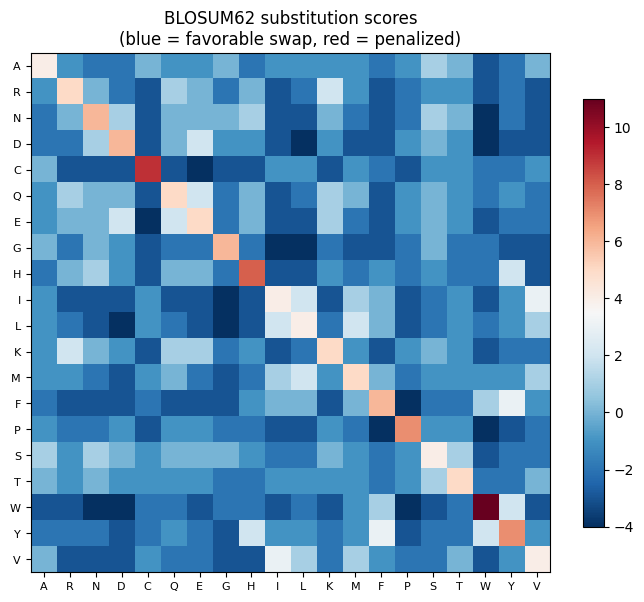

In [8]:
_COL = {"match": "#1b7837", "mismatch": "#d95f0e", "gap": "#9e9e9e"}


def show_alignment(res, width=60, max_cols=180, title=None):
    top, bottom = res["top"], res["bottom"]
    st = alignment_stats(res)
    total = len(top)
    shown = total if (max_cols is None) else min(total, max_cols)

    head = title or f'{res["name1"]}  vs  {res["name2"]}'
    parts = [f'<div style="font-family:monospace;font-size:13px;line-height:1.35">']
    parts.append(f'<b>{head}</b> &nbsp; <span style="color:#555">'
                 f'[{res["mode"]} alignment, gap penalty {res["gap"]}]</span><br>')

    def cell(ch_top, ch_bot):
        if ch_top == "-" or ch_bot == "-":
            bg = _COL["gap"]; mid = " "
        elif ch_top == ch_bot:
            bg = _COL["match"]; mid = "|"
        else:
            bg = _COL["mismatch"]; mid = "."
        return bg, mid

    for start in range(0, shown, width):
        end = min(start + width, shown)
        row_t = []; row_m = []; row_b = []
        for k in range(start, end):
            bg, mid = cell(top[k], bottom[k])
            row_t.append(f'<span style="background:{bg};color:white">{top[k]}</span>')
            row_b.append(f'<span style="background:{bg};color:white">{bottom[k]}</span>')
            row_m.append(mid)
        parts.append(f'<div style="white-space:pre">{"".join(row_t)}   {end}</div>')
        parts.append(f'<div style="white-space:pre;color:#333">{"".join(row_m)}</div>')
        parts.append(f'<div style="white-space:pre">{"".join(row_b)}</div>')
        parts.append('<div style="height:6px"></div>')

    if shown < total:
        parts.append(f'<div style="color:#a00">... showing first {shown} of {total} columns '
                     f'(statistics below cover all {total}).</div>')

    parts.append(
        '<table style="font-family:sans-serif;font-size:13px;border-collapse:collapse;margin-top:6px">'
        + "".join(
            f'<tr><td style="padding:2px 10px;color:#555">{k}</td>'
            f'<td style="padding:2px 10px"><b>{v}</b></td></tr>'
            for k, v in [
                ("score", f'{st["score"]:.1f}'),
                ("percent identity", f'{st["percent_identity"]:.1f}%  ({st["matches"]}/{st["matches"]+st["mismatches"]})'),
                ("aligned length", f'{st["columns"]} columns'),
                ("mismatches", st["mismatches"]),
                ("number of gaps", st["num_gaps"]),
                ("total gap columns", f'{st["gap_columns"]}  ({st["percent_gaps"]:.1f}%)'),
                ("longest gap", st["longest_gap"]),
            ])
        + "</table></div>")
    display(HTML("".join(parts)))
    return st


def matrix_heatmap(name):
    M = MATRICES[name]
    letters = [a for a in PROTEIN_ALPHABET if a not in "BZX*"]
    grid = [[M[a][b] for b in letters] for a in letters]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(grid, cmap="RdBu_r", vmin=-4, vmax=11)
    ax.set_xticks(range(len(letters))); ax.set_xticklabels(letters, fontsize=8)
    ax.set_yticks(range(len(letters))); ax.set_yticklabels(letters, fontsize=8)
    ax.set_title(f"{name} substitution scores\n(blue = favorable swap, red = penalized)")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()


# demo
_demo = align("ACGTGACCTGATCA", "ACGTAACCTGGTCA", dna_matrix(1, 1), 2, "global",
              name1="demo_1", name2="demo_2")
show_alignment(_demo)
matrix_heatmap("BLOSUM62")

## 5. The interactive app

The cell below embeds the example sequences, then builds the app. Pick **DNA or Protein**, **global or
local**, load an **example**, and drag the sliders — the alignment and its readouts redraw live. For DNA you
tune match / mismatch / gap; for protein you pick a **scoring matrix** and the gap penalty.

*(The big SARS spike sequences are also embedded, but they are handled in their own section below rather than
in the live-slider app, so the sliders stay snappy.)*

In [9]:
# ---- embedded sequences (all real; accessions noted) ----
# Toy pair: seq2 is seq1 with a few point substitutions.
TOY_1 = "ACGTGTCATGCATTAGCATGACTAGCATCGATCG"
TOY_2 = "ACGTATCATGCATTTGCATGACAAGCATCGATCG"

# HBB (hemoglobin subunit beta) coding DNA -- NCBI RefSeq
HBB_HUMAN_DNA = (
    'ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAG'
    'TTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGG'
    'GGATCTGTCCACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGT'
    'GCCTTTAGTGATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACT'
    'GTGACAAGCTGCACGTGGATCCTGAGAACTTCAGGCTCCTGGGCAACGTGCTGGTCTGTGTGCTGGCCCA'
    'TCACTTTGGCAAAGAATTCACCCCACCAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGTGTGGCTAAT'
    'GCCCTGGCCCACAAGTATCACTAA'
)   # NM_000518.5
HBB_MOUSE_DNA = (
    'ATGGTGCACCTGACTGATGCTGAGAAGGCTGCTGTCTCTGGCCTGTGGGGAAAGGTGAACGCCGATGAAG'
    'TTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTTGTCTACCCTTGGACCCAGCGGTACTTTGATAGCTTTGG'
    'AGACCTATCCTCTGCCTCTGCTATCATGGGTAATGCCAAAGTGAAGGCCCATGGCAAGAAAGTGATAACT'
    'GCCTTTAACGATGGCCTGAATCACTTGGACAGCCTCAAGGGCACCTTTGCCAGCCTCAGTGAGCTCCACT'
    'GTGACAAGCTGCATGTGGATCCTGAGAACTTCAGGCTCCTGGGCAATATGATCGTGATTGTGCTGGGCCA'
    'CCACCTGGGCAAGGATTTCACCCCCGCTGCACAGGCTGCCTTCCAGAAGGTGGTGGCTGGAGTGGCTGCT'
    'GCCCTGGCTCACAAGTACCACTAA'
)   # NM_008220.5

# HBB protein (UniProt)
HBB_HUMAN_AA = (
    'MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLG'
    'AFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVAN'
    'ALAHKYH'
)   # P68871
HBB_GORILLA_AA = (
    'MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLG'
    'AFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFKLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVAN'
    'ALAHKYH'
)   # P02024
HBB_COW_AA = (
    'MLSAEEKAAVTSLFAKVKVDEVGGEALGRLLVVYPWTQRFFESFGDLSSADAILGNPKVKAHGKKVLDSF'
    'CEGLKQLDDLKGAFASLSELHCDKLHVDPENFRLLGNVLVVVLARRFGSEFSPELQASFQKVVTGVANAL'
    'AHRYH'
)   # P02081
HBB_ZEBRAFISH_AA = (
    'MVEWTDAERTAILGLWGKLNIDEIGPQALSRCLIVYPWTQRYFATFGNLSSPAAIMGNPKVAAHGRTVMG'
    'GLERAIKNMDNVKNTYAALSVMHSEKLHVDPDNFRLLADCITVCAAMKFGQAGFNADVQEAWQKFLAVVV'
    'SALCRQYH'
)   # Q90486

# SARS coronavirus spike: coding DNA and protein
SARS1_SPIKE_DNA = (
    'ATGTTTATTTTCTTATTATTTCTTACTCTCACTAGTGGTAGTGACCTTGACCGGTGCACCACTTTTGATG'
    'ATGTTCAAGCTCCTAATTACACTCAACATACTTCATCTATGAGGGGGGTTTACTATCCTGATGAAATTTT'
    'TAGATCAGACACTCTTTATTTAACTCAGGATTTATTTCTTCCATTTTATTCTAATGTTACAGGGTTTCAT'
    'ACTATTAATCATACGTTTGGCAACCCTGTCATACCTTTTAAGGATGGTATTTATTTTGCTGCCACAGAGA'
    'AATCAAATGTTGTCCGTGGTTGGGTTTTTGGTTCTACCATGAACAACAAGTCACAGTCGGTGATTATTAT'
    'TAACAATTCTACTAATGTTGTTATACGAGCATGTAACTTTGAATTGTGTGACAACCCTTTCTTTGCTGTT'
    'TCTAAACCCATGGGTACACAGACACATACTATGATATTCGATAATGCATTTAATTGCACTTTCGAGTACA'
    'TATCTGATGCCTTTTCGCTTGATGTTTCAGAAAAGTCAGGTAATTTTAAACACTTACGAGAGTTTGTGTT'
    'TAAAAATAAAGATGGGTTTCTCTATGTTTATAAGGGCTATCAACCTATAGATGTAGTTCGTGATCTACCT'
    'TCTGGTTTTAACACTTTGAAACCTATTTTTAAGTTGCCTCTTGGTATTAACATTACAAATTTTAGAGCCA'
    'TTCTTACAGCCTTTTCACCTGCTCAAGACATTTGGGGCACGTCAGCTGCAGCCTATTTTGTTGGCTATTT'
    'AAAGCCAACTACATTTATGCTCAAGTATGATGAAAATGGTACAATCACAGATGCTGTTGATTGTTCTCAA'
    'AATCCACTTGCTGAACTCAAATGCTCTGTTAAGAGCTTTGAGATTGACAAAGGAATTTACCAGACCTCTA'
    'ATTTCAGGGTTGTTCCCTCAGGAGATGTTGTGAGATTCCCTAATATTACAAACTTGTGTCCTTTTGGAGA'
    'GGTTTTTAATGCTACTAAATTCCCTTCTGTCTATGCATGGGAGAGAAAAAAAATTTCTAATTGTGTTGCT'
    'GATTACTCTGTGCTCTACAACTCAACATTTTTTTCAACCTTTAAGTGCTATGGCGTTTCTGCCACTAAGT'
    'TGAATGATCTTTGCTTCTCCAATGTCTATGCAGATTCTTTTGTAGTCAAGGGAGATGATGTAAGACAAAT'
    'AGCGCCAGGACAAACTGGTGTTATTGCTGATTATAATTATAAATTGCCAGATGATTTCATGGGTTGTGTC'
    'CTTGCTTGGAATACTAGGAACATTGATGCTACTTCAACTGGTAATTATAATTATAAATATAGGTATCTTA'
    'GACATGGCAAGCTTAGGCCCTTTGAGAGAGACATATCTAATGTGCCTTTCTCCCCTGATGGCAAACCTTG'
    'CACCCCACCTGCTCTTAATTGTTATTGGCCATTAAATGATTATGGTTTTTACACCACTACTGGCATTGGC'
    'TACCAACCTTACAGAGTTGTAGTACTTTCTTTTGAACTTTTAAATGCACCGGCCACGGTTTGTGGACCAA'
    'AATTATCCACTGACCTTATTAAGAACCAGTGTGTCAATTTTAATTTTAATGGACTCACTGGTACTGGTGT'
    'GTTAACTCCTTCTTCAAAGAGATTTCAACCATTTCAACAATTTGGCCGTGATGTTTCTGATTTCACTGAT'
    'TCCGTTCGAGATCCTAAAACATCTGAAATATTAGACATTTCACCTTGCGCTTTTGGGGGTGTAAGTGTAA'
    'TTACACCTGGAACAAATGCTTCATCTGAAGTTGCTGTTCTATATCAAGATGTTAACTGCACTGATGTTTC'
    'TACAGCAATTCATGCAGATCAACTCACACCAGCTTGGCGCATATATTCTACTGGAAACAATGTATTCCAG'
    'ACTCAAGCAGGCTGTCTTATAGGAGCTGAGCATGTCGACACTTCTTATGAGTGCGACATTCCTATTGGAG'
    'CTGGCATTTGTGCTAGTTACCATACAGTTTCTTTATTACGTAGTACTAGCCAAAAATCTATTGTGGCTTA'
    'TACTATGTCTTTAGGTGCTGATAGTTCAATTGCTTACTCTAATAACACCATTGCTATACCTACTAACTTT'
    'TCAATTAGCATTACTACAGAAGTAATGCCTGTTTCTATGGCTAAAACCTCCGTAGATTGTAATATGTACA'
    'TCTGCGGAGATTCTACTGAATGTGCTAATTTGCTTCTCCAATATGGTAGCTTTTGCACACAACTAAATCG'
    'TGCACTCTCAGGTATTGCTGCTGAACAGGATCGCAACACACGTGAAGTGTTCGCTCAAGTCAAACAAATG'
    'TACAAAACCCCAACTTTGAAATATTTTGGTGGTTTTAATTTTTCACAAATATTACCTGACCCTCTAAAGC'
    'CAACTAAGAGGTCTTTTATTGAGGACTTGCTCTTTAATAAGGTGACACTCGCTGATGCTGGCTTCATGAA'
    'GCAATATGGCGAATGCCTAGGTGATATTAATGCTAGAGATCTCATTTGTGCGCAGAAGTTCAATGGACTT'
    'ACAGTGTTGCCACCTCTGCTCACTGATGATATGATTGCTGCCTACACTGCTGCTCTAGTTAGTGGTACTG'
    'CCACTGCTGGATGGACATTTGGTGCTGGCGCTGCTCTTCAAATACCTTTTGCTATGCAAATGGCATATAG'
    'GTTCAATGGCATTGGAGTTACCCAAAATGTTCTCTATGAGAACCAAAAACAAATCGCCAACCAATTTAAC'
    'AAGGCGATTAGTCAAATTCAAGAATCACTTACAACAACATCAACTGCATTGGGCAAGCTGCAAGACGTTG'
    'TTAACCAGAATGCTCAAGCATTAAACACACTTGTTAAACAACTTAGCTCTAATTTTGGTGCAATTTCAAG'
    'TGTGCTAAATGATATCCTTTCGCGACTTGATAAAGTCGAGGCGGAGGTACAAATTGACAGGTTAATTACA'
    'GGCAGACTTCAAAGCCTTCAAACCTATGTAACACAACAACTAATCAGGGCTGCTGAAATCAGGGCTTCTG'
    'CTAATCTTGCTGCTACTAAAATGTCTGAGTGTGTTCTTGGACAATCAAAAAGAGTTGACTTTTGTGGAAA'
    'GGGCTACCACCTTATGTCCTTCCCACAAGCAGCCCCGCATGGTGTTGTCTTCCTACATGTCACGTATGTG'
    'CCATCCCAGGAGAGGAACTTCACCACAGCGCCAGCAATTTGTCATGAAGGCAAAGCATACTTCCCTCGTG'
    'AAGGTGTTTTTGTGTTTAATGGCACTTCTTGGTTTATTACACAGAGGAACTTCTTTTCTCCACAAATAAT'
    'TACTACAGACAATACATTTGTCTCAGGAAATTGTGATGTCGTTATTGGCATCATTAACAACACAGTTTAT'
    'GATCCTCTGCAACCTGAGCTTGACTCATTCAAAGAAGAGCTGGACAAGTACTTCAAAAATCATACATCAC'
    'CAGATGTTGATCTTGGCGACATTTCAGGCATTAACGCTTCTGTCGTCAACATTCAAAAAGAAATTGACCG'
    'CCTCAATGAGGTCGCTAAAAATTTAAATGAATCACTCATTGACCTTCAAGAATTGGGAAAATATGAGCAA'
    'TATATTAAATGGCCTTGGTATGTTTGGCTCGGCTTCATTGCTGGACTAATTGCCATCGTCATGGTTACAA'
    'TCTTGCTTTGTTGCATGACTAGTTGTTGCAGTTGCCTCAAGGGTGCATGCTCTTGTGGTTCTTGCTGCAA'
    'GTTTGATGAGGATGACTCTGAGCCAGTTCTCAAGGGTGTCAAATTACATTACACA'
)   # SARS-CoV (2003) spike CDS
SARS2_SPIKE_DNA = (
    'ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAATCTTACAACCAGAACTCAAT'
    'TACCCCCTGCATACACTAATTCTTTCACACGTGGTGTTTATTACCCTGACAAAGTTTTCAGATCCTCAGT'
    'TTTACATTCAACTCAGGACTTGTTCTTACCTTTCTTTTCCAATGTTACTTGGTTCCATGCTATACATGTC'
    'TCTGGGACCAATGGTACTAAGAGGTTTGATAACCCTGTCCTACCATTTAATGATGGTGTTTATTTTGCTT'
    'CCACTGAGAAGTCTAACATAATAAGAGGCTGGATTTTTGGTACTACTTTAGATTCGAAGACCCAGTCCCT'
    'ACTTATTGTTAATAACGCTACTAATGTTGTTATTAAAGTCTGTGAATTTCAATTTTGTAATGATCCATTT'
    'TTGGGTGTTTATTACCACAAAAACAACAAAAGTTGGATGGAAAGTGAGTTCAGAGTTTATTCTAGTGCGA'
    'ATAATTGCACTTTTGAATATGTCTCTCAGCCTTTTCTTATGGACCTTGAAGGAAAACAGGGTAATTTCAA'
    'AAATCTTAGGGAATTTGTGTTTAAGAATATTGATGGTTATTTTAAAATATATTCTAAGCACACGCCTATT'
    'AATTTAGTGCGTGATCTCCCTCAGGGTTTTTCGGCTTTAGAACCATTGGTAGATTTGCCAATAGGTATTA'
    'ACATCACTAGGTTTCAAACTTTACTTGCTTTACATAGAAGTTATTTGACTCCTGGTGATTCTTCTTCAGG'
    'TTGGACAGCTGGTGCTGCAGCTTATTATGTGGGTTATCTTCAACCTAGGACTTTTCTATTAAAATATAAT'
    'GAAAATGGAACCATTACAGATGCTGTAGACTGTGCACTTGACCCTCTCTCAGAAACAAAGTGTACGTTGA'
    'AATCCTTCACTGTAGAAAAAGGAATCTATCAAACTTCTAACTTTAGAGTCCAACCAACAGAATCTATTGT'
    'TAGATTTCCTAATATTACAAACTTGTGCCCTTTTGGTGAAGTTTTTAACGCCACCAGATTTGCATCTGTT'
    'TATGCTTGGAACAGGAAGAGAATCAGCAACTGTGTTGCTGATTATTCTGTCCTATATAATTCCGCATCAT'
    'TTTCCACTTTTAAGTGTTATGGAGTGTCTCCTACTAAATTAAATGATCTCTGCTTTACTAATGTCTATGC'
    'AGATTCATTTGTAATTAGAGGTGATGAAGTCAGACAAATCGCTCCAGGGCAAACTGGAAAGATTGCTGAT'
    'TATAATTATAAATTACCAGATGATTTTACAGGCTGCGTTATAGCTTGGAATTCTAACAATCTTGATTCTA'
    'AGGTTGGTGGTAATTATAATTACCTGTATAGATTGTTTAGGAAGTCTAATCTCAAACCTTTTGAGAGAGA'
    'TATTTCAACTGAAATCTATCAGGCCGGTAGCACACCTTGTAATGGTGTTGAAGGTTTTAATTGTTACTTT'
    'CCTTTACAATCATATGGTTTCCAACCCACTAATGGTGTTGGTTACCAACCATACAGAGTAGTAGTACTTT'
    'CTTTTGAACTTCTACATGCACCAGCAACTGTTTGTGGACCTAAAAAGTCTACTAATTTGGTTAAAAACAA'
    'ATGTGTCAATTTCAACTTCAATGGTTTAACAGGCACAGGTGTTCTTACTGAGTCTAACAAAAAGTTTCTG'
    'CCTTTCCAACAATTTGGCAGAGACATTGCTGACACTACTGATGCTGTCCGTGATCCACAGACACTTGAGA'
    'TTCTTGACATTACACCATGTTCTTTTGGTGGTGTCAGTGTTATAACACCAGGAACAAATACTTCTAACCA'
    'GGTTGCTGTTCTTTATCAGGATGTTAACTGCACAGAAGTCCCTGTTGCTATTCATGCAGATCAACTTACT'
    'CCTACTTGGCGTGTTTATTCTACAGGTTCTAATGTTTTTCAAACACGTGCAGGCTGTTTAATAGGGGCTG'
    'AACATGTCAACAACTCATATGAGTGTGACATACCCATTGGTGCAGGTATATGCGCTAGTTATCAGACTCA'
    'GACTAATTCTCCTCGGCGGGCACGTAGTGTAGCTAGTCAATCCATCATTGCCTACACTATGTCACTTGGT'
    'GCAGAAAATTCAGTTGCTTACTCTAATAACTCTATTGCCATACCCACAAATTTTACTATTAGTGTTACCA'
    'CAGAAATTCTACCAGTGTCTATGACCAAGACATCAGTAGATTGTACAATGTACATTTGTGGTGATTCAAC'
    'TGAATGCAGCAATCTTTTGTTGCAATATGGCAGTTTTTGTACACAATTAAACCGTGCTTTAACTGGAATA'
    'GCTGTTGAACAAGACAAAAACACCCAAGAAGTTTTTGCACAAGTCAAACAAATTTACAAAACACCACCAA'
    'TTAAAGATTTTGGTGGTTTTAATTTTTCACAAATATTACCAGATCCATCAAAACCAAGCAAGAGGTCATT'
    'TATTGAAGATCTACTTTTCAACAAAGTGACACTTGCAGATGCTGGCTTCATCAAACAATATGGTGATTGC'
    'CTTGGTGATATTGCTGCTAGAGACCTCATTTGTGCACAAAAGTTTAACGGCCTTACTGTTTTGCCACCTT'
    'TGCTCACAGATGAAATGATTGCTCAATACACTTCTGCACTGTTAGCGGGTACAATCACTTCTGGTTGGAC'
    'CTTTGGTGCAGGTGCTGCATTACAAATACCATTTGCTATGCAAATGGCTTATAGGTTTAATGGTATTGGA'
    'GTTACACAGAATGTTCTCTATGAGAACCAAAAATTGATTGCCAACCAATTTAATAGTGCTATTGGCAAAA'
    'TTCAAGACTCACTTTCTTCCACAGCAAGTGCACTTGGAAAACTTCAAGATGTGGTCAACCAAAATGCACA'
    'AGCTTTAAACACGCTTGTTAAACAACTTAGCTCCAATTTTGGTGCAATTTCAAGTGTTTTAAATGATATC'
    'CTTTCACGTCTTGACAAAGTTGAGGCTGAAGTGCAAATTGATAGGTTGATCACAGGCAGACTTCAAAGTT'
    'TGCAGACATATGTGACTCAACAATTAATTAGAGCTGCAGAAATCAGAGCTTCTGCTAATCTTGCTGCTAC'
    'TAAAATGTCAGAGTGTGTACTTGGACAATCAAAAAGAGTTGATTTTTGTGGAAAGGGCTATCATCTTATG'
    'TCCTTCCCTCAGTCAGCACCTCATGGTGTAGTCTTCTTGCATGTGACTTATGTCCCTGCACAAGAAAAGA'
    'ACTTCACAACTGCTCCTGCCATTTGTCATGATGGAAAAGCACACTTTCCTCGTGAAGGTGTCTTTGTTTC'
    'AAATGGCACACACTGGTTTGTAACACAAAGGAATTTTTATGAACCACAAATCATTACTACAGACAACACA'
    'TTTGTGTCTGGTAACTGTGATGTTGTAATAGGAATTGTCAACAACACAGTTTATGATCCTTTGCAACCTG'
    'AATTAGACTCATTCAAGGAGGAGTTAGATAAATATTTTAAGAATCATACATCACCAGATGTTGATTTAGG'
    'TGACATCTCTGGCATTAATGCTTCAGTTGTAAACATTCAAAAAGAAATTGACCGCCTCAATGAGGTTGCC'
    'AAGAATTTAAATGAATCTCTCATCGATCTCCAAGAACTTGGAAAGTATGAGCAGTATATAAAATGGCCAT'
    'GGTACATTTGGCTAGGTTTTATAGCTGGCTTGATTGCCATAGTAATGGTGACAATTATGCTTTGCTGTAT'
    'GACCAGTTGCTGTAGTTGTCTCAAGGGCTGTTGTTCTTGTGGATCCTGCTGCAAATTTGATGAAGACGAC'
    'TCTGAGCCAGTGCTCAAAGGAGTCAAATTACATTACACATAA'
)   # SARS-CoV-2 spike CDS
SARS1_SPIKE_AA = (
    'MFIFLLFLTLTSGSDLDRCTTFDDVQAPNYTQHTSSMRGVYYPDEIFRSDTLYLTQDLFLPFYSNVTGFH'
    'TINHTFGNPVIPFKDGIYFAATEKSNVVRGWVFGSTMNNKSQSVIIINNSTNVVIRACNFELCDNPFFAV'
    'SKPMGTQTHTMIFDNAFNCTFEYISDAFSLDVSEKSGNFKHLREFVFKNKDGFLYVYKGYQPIDVVRDLP'
    'SGFNTLKPIFKLPLGINITNFRAILTAFSPAQDIWGTSAAAYFVGYLKPTTFMLKYDENGTITDAVDCSQ'
    'NPLAELKCSVKSFEIDKGIYQTSNFRVVPSGDVVRFPNITNLCPFGEVFNATKFPSVYAWERKKISNCVA'
    'DYSVLYNSTFFSTFKCYGVSATKLNDLCFSNVYADSFVVKGDDVRQIAPGQTGVIADYNYKLPDDFMGCV'
    'LAWNTRNIDATSTGNYNYKYRYLRHGKLRPFERDISNVPFSPDGKPCTPPALNCYWPLNDYGFYTTTGIG'
    'YQPYRVVVLSFELLNAPATVCGPKLSTDLIKNQCVNFNFNGLTGTGVLTPSSKRFQPFQQFGRDVSDFTD'
    'SVRDPKTSEILDISPCAFGGVSVITPGTNASSEVAVLYQDVNCTDVSTAIHADQLTPAWRIYSTGNNVFQ'
    'TQAGCLIGAEHVDTSYECDIPIGAGICASYHTVSLLRSTSQKSIVAYTMSLGADSSIAYSNNTIAIPTNF'
    'SISITTEVMPVSMAKTSVDCNMYICGDSTECANLLLQYGSFCTQLNRALSGIAAEQDRNTREVFAQVKQM'
    'YKTPTLKYFGGFNFSQILPDPLKPTKRSFIEDLLFNKVTLADAGFMKQYGECLGDINARDLICAQKFNGL'
    'TVLPPLLTDDMIAAYTAALVSGTATAGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKQIANQFN'
    'KAISQIQESLTTTSTALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQIDRLIT'
    'GRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLMSFPQAAPHGVVFLHVTYV'
    'PSQERNFTTAPAICHEGKAYFPREGVFVFNGTSWFITQRNFFSPQIITTDNTFVSGNCDVVIGIINNTVY'
    'DPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYEQ'
    'YIKWPWYVWLGFIAGLIAIVMVTILLCCMTSCCSCLKGACSCGSCCKFDEDDSEPVLKGVKLHYT'
)   # SARS-CoV spike protein
SARS2_SPIKE_AA = (
    'MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHV'
    'SGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPF'
    'LGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPI'
    'NLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYN'
    'ENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASV'
    'YAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIAD'
    'YNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYF'
    'PLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFL'
    'PFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLT'
    'PTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPRRARSVASQSIIAYTMSLG'
    'AENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGI'
    'AVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDC'
    'LGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIG'
    'VTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDI'
    'LSRLDKVEAEVQIDRLITGRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLM'
    'SFPQSAPHGVVFLHVTYVPAQEKNFTTAPAICHDGKAHFPREGVFVSNGTHWFVTQRNFYEPQIITTDNT'
    'FVSGNCDVVIGIVNNTVYDPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVA'
    'KNLNESLIDLQELGKYEQYIKWPWYIWLGFIAGLIAIVMVTIMLCCMTSCCSCLKGCCSCGSCCKFDEDD'
    'SEPVLKGVKLHYT'
)   # SARS-CoV-2 spike protein

EXAMPLES = {
    "toy DNA":            {"type": "DNA",     "s1": TOY_1,         "s2": TOY_2,          "n1": "toy_1",   "n2": "toy_2"},
    "HBB DNA human/mouse":{"type": "DNA",     "s1": HBB_HUMAN_DNA, "s2": HBB_MOUSE_DNA,  "n1": "human",   "n2": "mouse"},
    "HBB protein hum/gor":{"type": "Protein", "s1": HBB_HUMAN_AA,  "s2": HBB_GORILLA_AA, "n1": "human",   "n2": "gorilla"},
    "HBB protein hum/fish":{"type":"Protein", "s1": HBB_HUMAN_AA,  "s2": HBB_ZEBRAFISH_AA,"n1": "human",  "n2": "zebrafish"},
}
print("Embedded:", {k: (len(v["s1"]), len(v["s2"])) for k, v in EXAMPLES.items()})
print("SARS spike DNA:", len(SARS1_SPIKE_DNA), len(SARS2_SPIKE_DNA), "| protein:", len(SARS1_SPIKE_AA), len(SARS2_SPIKE_AA))

Embedded: {'toy DNA': (34, 34), 'HBB DNA human/mouse': (444, 444), 'HBB protein hum/gor': (147, 147), 'HBB protein hum/fish': (147, 148)}
SARS spike DNA: 3765 3822 | protein: 1255 1273


In [10]:
def run_aligner(s1, s2, seq_type="DNA", mode="global", match=1.0, mismatch=1.0,
                gap=2.0, matrix_name="BLOSUM62", name1="seq1", name2="seq2",
                width=60, max_cols=180, show=True):
    """Clean the inputs, pick the right scoring scheme, align, and (optionally) render."""
    a = clean(s1, seq_type); b = clean(s2, seq_type)
    sub = dna_matrix(match, mismatch) if seq_type == "DNA" else MATRICES[matrix_name]
    res = align(a, b, sub, gap, mode, name1, name2)
    if show:
        show_alignment(res, width=width, max_cols=max_cols)
    return res


if HAVE_WIDGETS:
    W = widgets
    ex_dd   = W.Dropdown(options=list(EXAMPLES.keys()), value="toy DNA", description="Example:")
    typ     = W.ToggleButtons(options=["DNA", "Protein"], value="DNA", description="Type:")
    mode    = W.ToggleButtons(options=["global", "local"], value="global", description="Mode:")
    s1_box  = W.Textarea(value=EXAMPLES["toy DNA"]["s1"], description="Seq 1:",
                         layout=W.Layout(width="97%", height="55px"))
    s2_box  = W.Textarea(value=EXAMPLES["toy DNA"]["s2"], description="Seq 2:",
                         layout=W.Layout(width="97%", height="55px"))
    match_s = W.FloatSlider(value=1.0, min=0, max=10, step=0.5, description="match")
    mis_s   = W.FloatSlider(value=1.0, min=0, max=10, step=0.5, description="mismatch")
    gap_s   = W.FloatSlider(value=2.0, min=0, max=12, step=0.1, description="gap")
    mat_dd  = W.Dropdown(options=list(MATRICES.keys()), value="BLOSUM62", description="matrix")
    out     = W.Output()
    _busy   = {"v": False}

    def refresh(*_):
        with out:
            out.clear_output(wait=True)
            run_aligner(s1_box.value, s2_box.value, seq_type=typ.value, mode=mode.value,
                        match=match_s.value, mismatch=mis_s.value, gap=gap_s.value,
                        matrix_name=mat_dd.value, name1="seq1", name2="seq2")

    def on_type(*_):
        is_dna = (typ.value == "DNA")
        for w in (match_s, mis_s):
            w.layout.display = "" if is_dna else "none"
        mat_dd.layout.display = "none" if is_dna else ""
        refresh()

    def on_example(*_):
        ex = EXAMPLES[ex_dd.value]
        _busy["v"] = True
        typ.value = ex["type"]; s1_box.value = ex["s1"]; s2_box.value = ex["s2"]
        _busy["v"] = False
        on_type()

    for w in (typ, mode, s1_box, s2_box, match_s, mis_s, gap_s, mat_dd):
        w.observe(lambda *_: (None if _busy["v"] else refresh()), names="value")
    typ.observe(lambda *_: (None if _busy["v"] else on_type()), names="value")
    ex_dd.observe(on_example, names="value")

    controls = W.VBox([ex_dd, W.HBox([typ, mode]), s1_box, s2_box,
                       W.HBox([match_s, mis_s]), W.HBox([gap_s, mat_dd])])
    on_type()
    display(controls, out)
else:
    print("ipywidgets not available in this environment.")
    print("Use run_aligner(...) directly, e.g.:")
    run_aligner(TOY_1, TOY_2, seq_type="DNA", mode="global", match=1, mismatch=1, gap=2)

Output()

## 6. Good vs bad parameters

### 6a. Toy example

Two nearly identical DNA strings (`toy_1` vs `toy_2`) that differ by three point substitutions. The honest
alignment lays them side by side with three orange mismatches and **no gaps**.

Now the trap. Set the **gap penalty almost to zero** (and bump the rewards). Because a mismatch column now
costs more than gapping *around* it, the optimizer discovers it can replace every mismatch with a little
gap — reaching a **higher score and "100% identity"** while turning a clean 34-column alignment into a
gap-riddled staircase. It is *technically optimal for those parameters* and *biologically nonsense*.

In [11]:
print(">>> GOOD parameters: match=1, mismatch=1, gap=2")
good = run_aligner(TOY_1, TOY_2, "DNA", "global", match=1, mismatch=1, gap=2, name1="toy_1", name2="toy_2")

print("\n>>> BAD parameters: match=2, mismatch=2, gap=0.1  (gap almost free)")
bad = run_aligner(TOY_1, TOY_2, "DNA", "global", match=2, mismatch=2, gap=0.1, name1="toy_1", name2="toy_2")

>>> GOOD parameters: match=1, mismatch=1, gap=2


score,28.0
percent identity,91.2% (31/34)
aligned length,34 columns
mismatches,3
number of gaps,0
total gap columns,0 (0.0%)
longest gap,0



>>> BAD parameters: match=2, mismatch=2, gap=0.1  (gap almost free)


score,61.4
percent identity,100.0% (31/31)
aligned length,37 columns
mismatches,0
number of gaps,6
total gap columns,6 (16.2%)
longest gap,1


Notice the bad alignment reports **higher identity** than the good one. That is the whole lesson in
miniature: a bigger score and a prettier identity number came from mangling the biology. Percent identity,
read on its own, *rewarded* the vandalism — which is why the gap statistics next to it matter so much.

### 6b. A real gene: HBB coding DNA, human vs mouse

Same experiment on a real gene — the coding sequence of **hemoglobin subunit beta (HBB)** in human
(`NM_000518.5`) and mouse (`NM_008220.5`), 444 bp each. Good parameters give ~83% identity with essentially
no gaps — the expected picture for two mammalian orthologs. The near-free-gap parameters again inflate
identity to a meaningless **100%** by opening ~100 tiny gaps.

In [12]:
print(">>> GOOD: match=1, mismatch=1, gap=2")
run_aligner(HBB_HUMAN_DNA, HBB_MOUSE_DNA, "DNA", "global", match=1, mismatch=1, gap=2,
            name1="human_HBB", name2="mouse_HBB", max_cols=120)

print("\n>>> BAD: match=2, mismatch=2, gap=0.1")
run_aligner(HBB_HUMAN_DNA, HBB_MOUSE_DNA, "DNA", "global", match=2, mismatch=2, gap=0.1,
            name1="human_HBB", name2="mouse_HBB", max_cols=120)

>>> GOOD: match=1, mismatch=1, gap=2


score,293.0
percent identity,83.5% (370/443)
aligned length,445 columns
mismatches,73
number of gaps,2
total gap columns,2 (0.4%)
longest gap,1



>>> BAD: match=2, mismatch=2, gap=0.1


score,749.4
percent identity,100.0% (381/381)
aligned length,507 columns
mismatches,0
number of gaps,103
total gap columns,126 (24.9%)
longest gap,3


{'name1': 'human_HBB',
 'name2': 'mouse_HBB',
 'top': 'ATGGTGCA-TCTGACTCCTGA-G--GAGAA-GTCTGC-CGT-TACTG-CCCTGTGGGG-CAAGGTGAACG--TGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGCTGCTGG-TGGTCTACCCTTGGACCCAG-AGGT-TCTTTG--AGTCCTTTGG-GGA-TCT-GTCCACTCCTG--ATGCTG-T-T-ATGGG-CAA--CC-CTAAGGTGAAGG-CTCATGGCAAGAAAGTG-CT--CGGTGCCTTT-A-GTGATGGCCTG--GCTCAC-CTGGACA-ACCTCAAGGGCACCTTTGCCA-CACT-GAGTGAGCT-GCACTGTGACAAGCTGCA-CGTGGATCCTGAGAACTTCAGGCTCCTGGGCAACGT-GCTG-GTC-TG--TGTGCT-GG-C-CCATCACT-TTGGCAA-AGA-ATTCACCCCAC-CAGTG--CAGGCTGCCTAT-CAGAA-AGTGGTGGCTGG-TGTGGCT--AATGCCCTGGC-CCACAAGTA-TCACTAA',
 'bottom': 'ATGGTGCAC-CTGA---CTGATGCTGAGAAGG-CTGCT-GTCT-CTGG-CCTGTGGGGA-AAGGTGAACGCC--GATGAAGTTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTT-GTCTACCCTTGGACCCAGC-GGTA-CTTTGATAG--CTTTGGA-GAC-CTA-T-C-CT-CTGCC-T-CTGCTATCATGGGT-AATGCCA--AA-GTGAAGGCC-CATGGCAAGAAAGTGA-TAAC--TGCCTTTAAC--GATGGCCTGAA--TCACT-TGGACAG-CCTCAAGGGCACCTTTGCCAGC-CTC-AGTGAGCTC-CACTGTGACAAGCTGCAT-GTGGATCCTGAGAACTTCAGGCTCCTGGGCAA--TA--TGA-TCGTGATTGTGCTGGGCCACCA-C-CTG--GGCAAG-GAT-TTCA

### 6c. Protein: the scoring *matrix* is a parameter too

For proteins, the biggest knob is the matrix. Human vs **zebrafish** HBB are distant (~50% identical), so
conservative substitutions are everywhere. **BLOSUM62** knows that I↔V or L↔M are cheap and finds a clean,
nearly gap-free alignment. Replace it with a **flat +1/–1 "identity" matrix** — which treats every
substitution as equally bad, exactly like DNA — and, with a small gap penalty, the aligner shreds the protein
into gappy fragments chasing coincidental single-residue matches. It even reports *higher* raw identity,
which again is exactly the wrong thing to trust.

In [13]:
print(">>> GOOD: BLOSUM62, gap=11 (biochemically aware)")
run_aligner(HBB_HUMAN_AA, HBB_ZEBRAFISH_AA, "Protein", "global", gap=11, matrix_name="BLOSUM62",
            name1="human_HBB", name2="zebrafish_HBB")

print("\n>>> BAD: flat +1/-1 identity matrix, gap=0.5 (ignores biochemistry)")
_flat = {a: {b: (1 if a == b else -1) for b in PROTEIN_ALPHABET} for a in PROTEIN_ALPHABET}
_res = align(clean(HBB_HUMAN_AA, "Protein"), clean(HBB_ZEBRAFISH_AA, "Protein"), _flat, 0.5, "global",
             name1="human_HBB", name2="zebrafish_HBB")
show_alignment(_res)

print("\nThe matrix that encodes real biochemistry wins even though it reports LOWER raw identity.")

>>> GOOD: BLOSUM62, gap=11 (biochemically aware)


score,418.0
percent identity,51.7% (76/147)
aligned length,148 columns
mismatches,71
number of gaps,1
total gap columns,1 (0.7%)
longest gap,1



>>> BAD: flat +1/-1 identity matrix, gap=0.5 (ignores biochemistry)


score,18.5
percent identity,61.0% (83/136)
aligned length,159 columns
mismatches,53
number of gaps,11
total gap columns,23 (14.5%)
longest gap,4



The matrix that encodes real biochemistry wins even though it reports LOWER raw identity.


## 7. DNA vs protein — SARS-CoV vs SARS-CoV-2 spike

Now the centerpiece. I globally align the **spike** of SARS-CoV (the 2003 virus) and SARS-CoV-2 (COVID-19)
two ways: as **coding DNA**, then as the **protein** it encodes. The DNA is aligned with my flat DNA scoring;
the protein with BLOSUM62.

In [14]:
print("Aligning spike DNA (this fills a ~3800 x 3800 table; ~5-10 s)...")
dna_res = align(SARS1_SPIKE_DNA, SARS2_SPIKE_DNA, dna_matrix(1, 1), 2, "global",
                name1="SARS-CoV spike (DNA)", name2="SARS-CoV-2 spike (DNA)")
dna_st = show_alignment(dna_res, max_cols=120, title="Spike as DNA")

print("\nAligning spike PROTEIN (BLOSUM62)...")
aa_res = align(SARS1_SPIKE_AA, SARS2_SPIKE_AA, MATRICES["BLOSUM62"], 11, "global",
               name1="SARS-CoV spike (protein)", name2="SARS-CoV-2 spike (protein)")
aa_st = show_alignment(aa_res, max_cols=120, title="Spike as protein")

print(f"\nDNA identity     : {dna_st['percent_identity']:.1f}%")
print(f"Protein identity : {aa_st['percent_identity']:.1f}%")
print("The protein is MORE conserved than the gene that encodes it. Why? -> synonymous mutations.")

Aligning spike DNA (this fills a ~3800 x 3800 table; ~5-10 s)...


score,1767.0
percent identity,77.3% (2880/3727)
aligned length,3860 columns
mismatches,847
number of gaps,95
total gap columns,133 (3.4%)
longest gap,6



Aligning spike PROTEIN (BLOSUM62)...


score,5064.0
percent identity,78.0% (976/1251)
aligned length,1277 columns
mismatches,275
number of gaps,17
total gap columns,26 (2.0%)
longest gap,5



DNA identity     : 77.3%
Protein identity : 78.0%
The protein is MORE conserved than the gene that encodes it. Why? -> synonymous mutations.


### The synonymous-mutation analysis

A change in the DNA does not always change the protein. The genetic code is **degenerate**: most amino acids
have several codons, usually differing only at the **third position** (the "wobble" base). A DNA substitution
that swaps one synonymous codon for another (`GCT`→`GCC`, both Alanine) is completely **invisible** in the
protein.

To measure this, I anchor on the **protein** alignment (which keeps the reading frame honest) and, for every
aligned amino-acid column, compare the underlying codons from each DNA. Each pair is one of:
- **identical** — same amino acid, same codon;
- **synonymous** — different codon, **same** amino acid (visible in DNA, invisible in protein);
- **missense** — different amino acid (visible in both).

aligned codon columns : identical 538 | synonymous 438 | missense 275 | indel 26
codons that DIFFER in DNA: 713
   synonymous (protein unchanged): 438  (61%)
   missense   (protein changed)  : 275  (39%)
nucleotide substitutions by codon position: 1st 243 | 2nd 130 | 3rd 609  (3rd/wobble = 62%)
example synonymous codons: ['TTC->TTT (both F)', 'TTA->CTT (both L)', 'CTT->TTG (both L)', 'CTC->CTA (both L)']
example missense codons  : ['ATT(I)->GTT(V)', 'TTA(L)->GTT(V)', 'TTT(F)->TTA(L)', 'ACT(T)->CCA(P)']


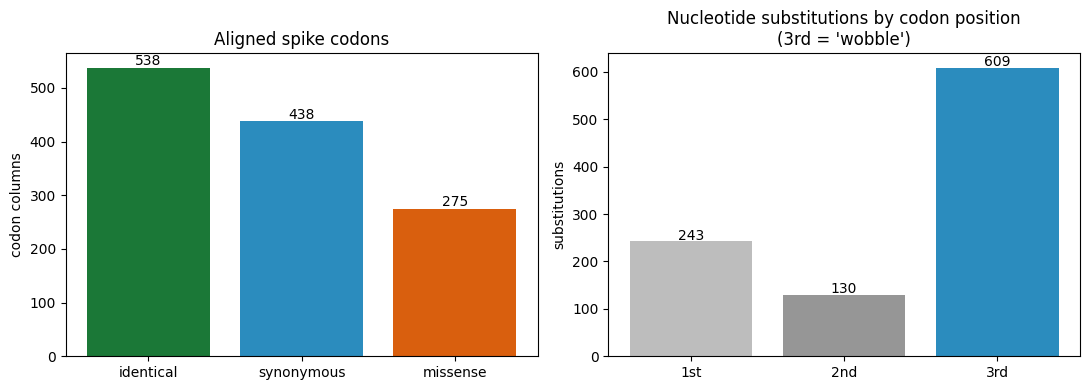

In [15]:
CODON = {
 'TTT':'F','TTC':'F','TTA':'L','TTG':'L','CTT':'L','CTC':'L','CTA':'L','CTG':'L',
 'ATT':'I','ATC':'I','ATA':'I','ATG':'M','GTT':'V','GTC':'V','GTA':'V','GTG':'V',
 'TCT':'S','TCC':'S','TCA':'S','TCG':'S','CCT':'P','CCC':'P','CCA':'P','CCG':'P',
 'ACT':'T','ACC':'T','ACA':'T','ACG':'T','GCT':'A','GCC':'A','GCA':'A','GCG':'A',
 'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*','CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
 'AAT':'N','AAC':'N','AAA':'K','AAG':'K','GAT':'D','GAC':'D','GAA':'E','GAG':'E',
 'TGT':'C','TGC':'C','TGA':'*','TGG':'W','CGT':'R','CGC':'R','CGA':'R','CGG':'R',
 'AGT':'S','AGC':'S','AGA':'R','AGG':'R','GGT':'G','GGC':'G','GGA':'G','GGG':'G'}

# walk the PROTEIN alignment; pull the matching codon from each DNA
c1 = c2 = 0
identical = synonymous = missense = indel = 0
pos_counts = {1: 0, 2: 0, 3: 0}
examples = {"synonymous": [], "missense": []}
for x, y in zip(aa_res["top"], aa_res["bottom"]):
    if x != "-" and y != "-":
        cod1 = SARS1_SPIKE_DNA[3*c1:3*c1+3]
        cod2 = SARS2_SPIKE_DNA[3*c2:3*c2+3]
        if x == y and cod1 == cod2:
            identical += 1
        elif x == y and cod1 != cod2:
            synonymous += 1
            for k in range(3):
                if cod1[k] != cod2[k]:
                    pos_counts[k+1] += 1
            if len(examples["synonymous"]) < 4:
                examples["synonymous"].append(f"{cod1}->{cod2} (both {x})")
        else:
            missense += 1
            for k in range(3):
                if cod1[k] != cod2[k]:
                    pos_counts[k+1] += 1
            if len(examples["missense"]) < 4:
                examples["missense"].append(f"{cod1}({x})->{cod2}({y})")
        c1 += 1; c2 += 1
    elif x != "-" and y == "-":
        c1 += 1; indel += 1
    else:
        c2 += 1; indel += 1

diff = synonymous + missense
print(f"aligned codon columns : identical {identical} | synonymous {synonymous} | missense {missense} | indel {indel}")
print(f"codons that DIFFER in DNA: {diff}")
print(f"   synonymous (protein unchanged): {synonymous}  ({100*synonymous/diff:.0f}%)")
print(f"   missense   (protein changed)  : {missense}  ({100*missense/diff:.0f}%)")
tot = sum(pos_counts.values())
print(f"nucleotide substitutions by codon position: "
      f"1st {pos_counts[1]} | 2nd {pos_counts[2]} | 3rd {pos_counts[3]}  "
      f"(3rd/wobble = {100*pos_counts[3]/tot:.0f}%)")
print("example synonymous codons:", examples["synonymous"])
print("example missense codons  :", examples["missense"])

# ---- figure ----
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
axL.bar(["identical", "synonymous", "missense"], [identical, synonymous, missense],
        color=["#1b7837", "#2b8cbe", "#d95f0e"])
axL.set_title("Aligned spike codons"); axL.set_ylabel("codon columns")
for i, v in enumerate([identical, synonymous, missense]):
    axL.text(i, v + 5, str(v), ha="center")
axR.bar(["1st", "2nd", "3rd"], [pos_counts[1], pos_counts[2], pos_counts[3]],
        color=["#bdbdbd", "#969696", "#2b8cbe"])
axR.set_title("Nucleotide substitutions by codon position\n(3rd = 'wobble')")
axR.set_ylabel("substitutions")
for i, v in enumerate([pos_counts[1], pos_counts[2], pos_counts[3]]):
    axR.text(i, v + 3, str(v), ha="center")
plt.tight_layout(); plt.show()

### Where the DNA and protein alignments disagree — and what it means

The DNA alignment sees **hundreds more differences** than the protein alignment does, and the two figures say
exactly why:

- Of the codons that differ at the DNA level, a **majority are synonymous** — the DNA changed but the amino
  acid did not. Those differences are real substitutions the DNA aligner faithfully paints orange, yet they
  **vanish** in the protein alignment.
- The substitutions pile up at the **third codon position** (the wobble base), precisely where the genetic
  code is most degenerate and a change is most likely to be synonymous. The first and second positions —
  where almost every change *does* alter the amino acid — are far quieter.

Biologically, this is the fingerprint of **purifying selection** on a functional protein. Mutations happen
across the gene, but the ones that change the protein are more often removed by selection, so they
accumulate more slowly than the "silent" third-position changes. That is why the **protein is more conserved
than its own gene**, and why the two alignments disagree.

**The punchline for the assignment:** the DNA alignment tells you *how much the sequence changed*; the protein
alignment tells you *how much of that change could actually matter to the organism*. Synonymous mutations are
the gap between those two numbers — they are the changes that DNA counts and biology ignores. If you want to
know which mutations matter, align the protein.

## 8. The central question: how do you quantify alignment quality?

> *Given that the score itself changes with your parameters, how would you quantify the quality of an
> alignment? Ground your answer in biology, not just the number your app reports.*

**Short answer:** the score is the optimizer's *objective*, not a measure of *truth*. "Quality" means *did the
alignment recover the real evolutionary or structural correspondence between the two sequences?* — and you
can't read that off the score, because the score is defined by the very parameters you're free to change.
Below is how I'd actually judge it, in four layers, and each one is demonstrated in code.

**1. The raw score is not comparable across parameter settings.** Take one *fixed* alignment and rescore it
under different parameters — the number moves even though not a single letter changed. Doubling the match
reward roughly doubles the score. So a bigger score never means a better alignment unless the scoring scheme
is held fixed. The cell below shows this directly.

**2. Use scale-free descriptors — but never identity alone.** Percent identity, gap count, longest gap, and
coverage don't depend on the reward units. But we already saw identity can be *inflated by gaps* (the toy and
HBB "bad" alignments hit ~100% identity by shredding the sequence). So quality is a **profile**: high identity
*and* few, sensible gaps *and* near-complete coverage. Any one number alone is gameable.

**3. Is it better than chance? (statistical significance.)** A "good" alignment should score far above what
random sequences of the same composition achieve. I estimate this by aligning the real sequence against many
**shuffled** versions of its partner and computing a z-score. This is the idea behind BLAST's E-value: it asks
"could this alignment have happened by luck?" rather than "is the number big?"

**4. Does it agree with biology we did not put into the scoring?** The ultimate check is external:
- **Reading frame** — for coding DNA, real indels come in multiples of 3 (they don't shift the frame). An
  alignment full of 1- and 2-base gaps inside a gene is almost certainly wrong, whatever it scores.
- **Known landmarks** — conserved motifs, active-site residues, cysteines forming disulfide bonds, or domain
  boundaries should line up. In our spike alignment the terminal `...KFDEDDSEPVLKGVKLHYT` matches perfectly —
  a real biological anchor, not an artifact of the score.
- **Structure / homology** — the gold standard is agreement with a structure-based alignment or a curated
  database. A number can't overrule a superposed 3-D structure.

**The honest bottom line:** there is no parameter-free definition of alignment quality, because alignment is
*inference* — a hypothesis about shared ancestry — not a measurement. The parameters *are* your evolutionary
model (how often substitutions vs. indels happen). A good alignment is one whose model is appropriate for the
sequences and whose result survives the checks above; the score only tells you it was optimal *for the model
you chose*. Quality is whether you chose the right model.

One FIXED human/mouse HBB alignment, rescored under different parameters:
  match=1 mismatch=1 gap=2  ->  score    293.0   (identity is unchanged at 83.5%)
  match=2 mismatch=1 gap=2  ->  score    663.0   (identity is unchanged at 83.5%)
  match=5 mismatch=1 gap=2  ->  score   1773.0   (identity is unchanged at 83.5%)
  match=1 mismatch=1 gap=1  ->  score    295.0   (identity is unchanged at 83.5%)

Significance test (HBB human vs zebrafish protein, BLOSUM62):


  real score 418;  shuffled mean -102.3, sd 19.1;  z = 27.2
  A z-score this large means the alignment is wildly better than chance -> the homology is real.


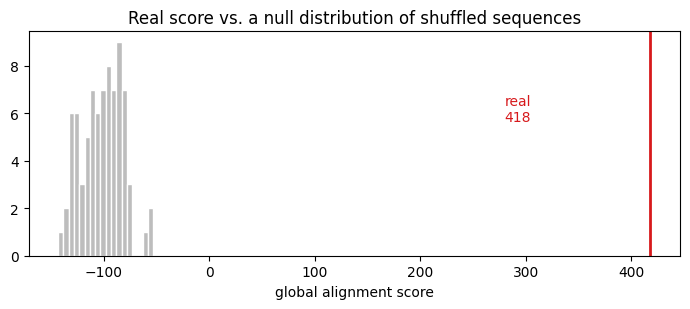

In [16]:
# ---- Layer 1: the same alignment, rescored under different parameters ----
fixed = align(HBB_HUMAN_DNA, HBB_MOUSE_DNA, dna_matrix(1, 1), 2, "global")
top, bot = fixed["top"], fixed["bottom"]
print("One FIXED human/mouse HBB alignment, rescored under different parameters:")
for (mt, mm, gp) in [(1, 1, 2), (2, 1, 2), (5, 1, 2), (1, 1, 1)]:
    print(f"  match={mt} mismatch={mm} gap={gp}  ->  score {_score_flat(top, bot, mt, mm, gp):8.1f}"
          f"   (identity is unchanged at {alignment_stats(fixed)['percent_identity']:.1f}%)")

# ---- Layer 3: significance by shuffling ----
print("\nSignificance test (HBB human vs zebrafish protein, BLOSUM62):")
real = align(HBB_HUMAN_AA, HBB_ZEBRAFISH_AA, MATRICES["BLOSUM62"], 11, "global")["score"]
rng = random.Random(0)
chars = list(clean(HBB_ZEBRAFISH_AA, "Protein"))
null = []
for _ in range(80):
    rng.shuffle(chars)
    null.append(align(clean(HBB_HUMAN_AA, "Protein"), "".join(chars), MATRICES["BLOSUM62"], 11, "global")["score"])
mu = sum(null) / len(null)
sd = (sum((x - mu) ** 2 for x in null) / len(null)) ** 0.5
print(f"  real score {real:.0f};  shuffled mean {mu:.1f}, sd {sd:.1f};  z = {(real - mu) / sd:.1f}")
print("  A z-score this large means the alignment is wildly better than chance -> the homology is real.")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(null, bins=18, color="#bdbdbd", edgecolor="white")
ax.axvline(real, color="#d7191c", lw=2)
ax.annotate(f"real\n{real:.0f}", xy=(real, 0), xytext=(real*0.7, ax.get_ylim()[1]*0.6),
            color="#d7191c", ha="center")
ax.set_title("Real score vs. a null distribution of shuffled sequences")
ax.set_xlabel("global alignment score"); plt.tight_layout(); plt.show()

## 9. Stretch — the gap problem (why gaps need smarter scoring)

> *Try to find one set of parameters that both allows a single long, realistic gap and discourages lots of
> scattered short gaps. You won't be able to. Why not?*

**Why not.** My gap scoring is **linear**: a gap of length $L$ costs $g \times L$. That means one gap of
length 10 (cost $10g$) is scored **exactly the same** as ten separate gaps of length 1 (also $10g$). The
scoring only sees *total gap length* — it is completely blind to whether the gaps are clustered into one
event or scattered everywhere. So there is no single value of $g$ that says "one long gap is fine, but many
short ones are not":

- Raise $g$ and you suppress **all** gaps — including the one real long indel, which then gets forced into a
  wall of mismatches.
- Lower $g$ and you invite **scattered** short gaps everywhere (exactly the pathology from Section 6).

Biology disagrees with linear scoring. A single insertion/deletion of 10 bases is **one** mutational
event — far more likely than 10 independent single-base indels that happen to land in a row. Real indels
cluster.

**The fix: affine gaps.** Charge a big one-time **open** penalty plus a small **extend** penalty per extra
base: $\text{cost}(L) = \text{open} + \text{extend} \times (L-1)$. Now one long gap pays *open* once, while
many short gaps each pay *open* — so the aligner finally prefers a single clean indel. Below: an affine
(Gotoh) aligner, a **rigorous proof** that no linear gap value can prefer one long gap over many short ones
(they *tie*, always), and a **picture** of linear scattering vs. affine clustering on a real-looking indel.

In [17]:
NEG = float("-inf")


def align_affine(seq1, seq2, sub, open_pen, extend_pen, name1="seq1", name2="seq2"):
    """Global alignment with affine gaps (Gotoh): cost(L) = open + extend*(L-1)."""
    n, m = len(seq1), len(seq2)
    M = [[NEG] * (m + 1) for _ in range(n + 1)]   # ...ending in a match/mismatch
    X = [[NEG] * (m + 1) for _ in range(n + 1)]   # ...ending in a gap in seq2 (consume seq1)
    Y = [[NEG] * (m + 1) for _ in range(n + 1)]   # ...ending in a gap in seq1 (consume seq2)
    M[0][0] = 0.0
    for i in range(1, n + 1):
        X[i][0] = -open_pen - (i - 1) * extend_pen
    for j in range(1, m + 1):
        Y[0][j] = -open_pen - (j - 1) * extend_pen
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            best_prev = max(M[i-1][j-1], X[i-1][j-1], Y[i-1][j-1])
            M[i][j] = sub[seq1[i-1]][seq2[j-1]] + best_prev
            X[i][j] = max(M[i-1][j] - open_pen, X[i-1][j] - extend_pen)
            Y[i][j] = max(M[i][j-1] - open_pen, Y[i][j-1] - extend_pen)
    # traceback
    i, j = n, m
    state = max((M[n][m], "M"), (X[n][m], "X"), (Y[n][m], "Y"))[1]
    score = max(M[n][m], X[n][m], Y[n][m])
    top = []; bot = []
    while i > 0 or j > 0:
        if state == "M":
            top.append(seq1[i-1]); bot.append(seq2[j-1])
            prev = max((M[i-1][j-1], "M"), (X[i-1][j-1], "X"), (Y[i-1][j-1], "Y"))[1]
            i -= 1; j -= 1; state = prev
        elif state == "X":
            top.append(seq1[i-1]); bot.append("-")
            opened = (X[i][j] == M[i-1][j] - open_pen)
            i -= 1; state = "M" if opened else "X"
        else:
            top.append("-"); bot.append(seq2[j-1])
            opened = (Y[i][j] == M[i][j-1] - open_pen)
            j -= 1; state = "M" if opened else "Y"
        if i == 0 and j == 0:
            break
        if i == 0 and j > 0:
            while j > 0:
                top.append("-"); bot.append(seq2[j-1]); j -= 1
            break
        if j == 0 and i > 0:
            while i > 0:
                top.append(seq1[i-1]); bot.append("-"); i -= 1
            break
    top.reverse(); bot.reverse()
    return {"name1": name1, "name2": name2, "top": "".join(top), "bottom": "".join(bot),
            "score": score, "mode": "global-affine", "gap": open_pen,
            "start1": 0, "end1": n, "start2": 0, "end2": m}


# sanity: affine with open==extend must equal my linear engine
_l = align("ACGTGTCATGCATTAGCATGACTAGCATCGATCG", "ACGTATCATGCATTTGCATGCATCGATCG", dna_matrix(1, 1), 2, "global")
_a = align_affine("ACGTGTCATGCATTAGCATGACTAGCATCGATCG", "ACGTATCATGCATTTGCATGCATCGATCG", dna_matrix(1, 1), 2, 2)
print(f"affine reduces to linear when open==extend:  linear {_l['score']}  ==  affine {_a['score']}  -> {_l['score']==_a['score']}")

# ---- PROOF: linear scoring cannot tell one long gap from many short ones ----
# Align ten A's to four A's: six A's must be gapped. Whether that gap is one block
# of 6 or three scattered pairs, the alignment has the SAME 4 matches and 6 gap
# columns -- so the LINEAR score is identical, for EVERY gap penalty.
block_top, block_bot = "AAAAAAAAAA", "AAAA------"
scat_top,  scat_bot  = "AAAAAAAAAA", "A--A--AA--"


def score_linear_rows(top, bot, match, gap):
    s = 0.0
    for x, y in zip(top, bot):
        if x == "-" or y == "-":
            s -= gap
        elif x == y:
            s += match
    return s


def score_affine_rows(top, bot, match, open_pen, extend_pen):
    s = 0.0
    for x, y in zip(top, bot):
        if x != "-" and y != "-" and x == y:
            s += match
    for seq in (top, bot):        # charge each gap run: open + extend*(length-1)
        run = 0
        for ch in seq + " ":
            if ch == "-":
                run += 1
            else:
                if run:
                    s -= open_pen + extend_pen * (run - 1)
                run = 0
    return s


print("Aligning ten A's to four A's (six A's must be gapped):")
print("  one block :", block_top, "/", block_bot)
print("  scattered :", scat_top, "/", scat_bot)
for g in (1, 2, 4):
    b = score_linear_rows(block_top, block_bot, 1, g)
    sc = score_linear_rows(scat_top, scat_bot, 1, g)
    verdict = "TIE - linear cannot prefer the single gap" if b == sc else "differ"
    print(f"  LINEAR gap={g}:  one block = {b:5.0f}   scattered = {sc:5.0f}   -> {verdict}")
b = score_affine_rows(block_top, block_bot, 1, 6, 1)
sc = score_affine_rows(scat_top, scat_bot, 1, 6, 1)
print(f"  AFFINE open=6 ext=1:  one block = {b:5.1f}   scattered = {sc:5.1f}   -> single gap wins by {b - sc:.0f}")

# ---- PICTURE: a real-looking indel next to a divergent tail ----
# A carries a genuine 10 bp insertion; the tail then diverges by a few point subs.
head = "ATGCGTACGTTAGCCA"
insert = "TTTTTTTTTT"                    # 10 bp, present only in A -> one true indel
tailA = "GACGATCAGTACGATCAG"
tailB = "GATGATAAGTCCGATCAG"             # tailA with a few spaced substitutions (same length)
A = head + insert + tailA
B = head + tailB
print("\nWith a cheap LINEAR gap, the divergent tail SHREDS into scattered gaps that erase the mismatches:")
show_alignment(align(A, B, dna_matrix(2, 3), 1, "global", name1="with_insert", name2="deletion"))
print("AFFINE keeps the ONE real 10 bp indel and reports the honest substitutions:")
show_alignment(align_affine(A, B, dna_matrix(2, 3), 6, 1, name1="with_insert", name2="deletion"))

affine reduces to linear when open==extend:  linear 15.0  ==  affine 15.0  -> True
Aligning ten A's to four A's (six A's must be gapped):
  one block : AAAAAAAAAA / AAAA------
  scattered : AAAAAAAAAA / A--A--AA--
  LINEAR gap=1:  one block =    -2   scattered =    -2   -> TIE - linear cannot prefer the single gap
  LINEAR gap=2:  one block =    -8   scattered =    -8   -> TIE - linear cannot prefer the single gap
  LINEAR gap=4:  one block =   -20   scattered =   -20   -> TIE - linear cannot prefer the single gap
  AFFINE open=6 ext=1:  one block =  -7.0   scattered = -17.0   -> single gap wins by 10

With a cheap LINEAR gap, the divergent tail SHREDS into scattered gaps that erase the mismatches:


score,46.0
percent identity,100.0% (31/31)
aligned length,47 columns
mismatches,0
number of gaps,7
total gap columns,16 (34.0%)
longest gap,10


AFFINE keeps the ONE real 10 bp indel and reports the honest substitutions:


score,38.0
percent identity,91.2% (31/34)
aligned length,44 columns
mismatches,3
number of gaps,1
total gap columns,10 (22.7%)
longest gap,10


{'score': 38.0,
 'columns': 44,
 'percent_identity': 91.17647058823529,
 'matches': 31,
 'mismatches': 3,
 'num_gaps': 1,
 'gap_columns': 10,
 'longest_gap': 10,
 'percent_gaps': 22.727272727272727}

The **proof** is the first block: aligning ten A's to four, a single 6-gap and three scattered 2-gaps
have *identical* linear score at every penalty — so no single gap value can favor the biologically likelier
single event; they always tie. Affine breaks the tie because opening a gap is expensive but extending it is
cheap.

The **picture** shows the fallout. A cheap linear gap erases real substitutions by scattering little gaps
around them (note the fake *0 mismatches* and the pile of gaps); affine keeps the single true 10 bp indel and
reports the honest substitutions. That two-parameter (open, extend) structure is exactly the knob linear
scoring lacks — which is why every serious tool (BLAST, EMBOSS, the Biopython aligner below) uses affine gaps
by default.

## 10. Stretch — sanity check against a tool the pros use

Do my numbers agree with an established library? I set Biopython's `PairwiseAligner` to the *same* model —
BLOSUM62 with a **linear** gap of 11 (open == extend) — and compare scores on the HBB proteins. They should
match to the decimal, because it's the same recurrence.

In [18]:
try:
    from Bio.Align import PairwiseAligner, substitution_matrices
except Exception:
    print("Installing biopython (Colab)..."); import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "biopython"])
    from Bio.Align import PairwiseAligner, substitution_matrices

bio = PairwiseAligner()
bio.mode = "global"
bio.substitution_matrix = substitution_matrices.load("BLOSUM62")
bio.open_gap_score = -11
bio.extend_gap_score = -11   # open == extend  => linear, to match my engine

for name, s2 in [("gorilla", HBB_GORILLA_AA), ("cow", HBB_COW_AA), ("zebrafish", HBB_ZEBRAFISH_AA)]:
    a = clean(HBB_HUMAN_AA, "Protein"); b = clean(s2, "Protein")
    ours = align(a, b, MATRICES["BLOSUM62"], 11, "global")["score"]
    theirs = bio.score(a, b)
    flag = "OK" if abs(ours - theirs) < 1e-6 else "MISMATCH"
    print(f"human vs {name:9}:  mine = {ours:7.1f}   biopython = {theirs:7.1f}   [{flag}]")

human vs gorilla  :  mine =   777.0   biopython =   777.0   [OK]


human vs cow      :  mine =   584.0   biopython =   584.0   [OK]


human vs zebrafish:  mine =   418.0   biopython =   418.0   [OK]


## 11. Conclusions

- **Change the scoring, change the alignment.** With a nearly free gap penalty, both the toy pair and the real
  HBB gene reached a *higher score and "100% identity"* by shattering into dozens of tiny gaps — technically
  optimal, biologically absurd. The good alignments told the honest story: a handful of point substitutions
  and essentially no gaps.
- **The number your app reports is not quality.** The raw score depends on the reward units, so it can't be
  compared across settings; percent identity can be inflated by gaps. Quality has to be judged as a *profile*
  (identity + gap structure + coverage), against **chance** (a shuffle/E-value test), and against **biology we
  didn't score for** (reading frame, conserved landmarks, structure).
- **DNA vs protein.** The spike protein is *more conserved than its own gene*, because the majority of the
  DNA differences are **synonymous** — concentrated at the wobble (3rd) codon position and invisible to the
  protein. The DNA alignment counts how much the sequence changed; the protein alignment shows how much of
  that change could matter. To find the mutations that matter, align the protein.
- **Gaps need smarter scoring.** Linear gap costs can't tell one real long indel from many scattered short
  ones; **affine** gaps (open + extend) fix it, which is why real tools use them — and my engine agrees with
  Biopython to the decimal.

*Built on my Module 2 code: `globalAlignment.py`, `globalAlignmentScore.py`, `localAlignment.py`,
`localAlignmentScore.py`, generalized here to substitution matrices and affine gaps.*
